<a href="https://colab.research.google.com/github/derVian/datascience/blob/main/DatascienceInternshipARIMA/SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
from statsmodels.tsa.stattools import adfuller


In [95]:
winter_df= pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_winter_daytime_daily.csv')
spring_df=pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_spring_daytime_daily.csv')
summer_df=pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_summer_daytime_daily.csv')
autumn_df=pd.read_csv('/content/drive/MyDrive/Colab_Data/dfp2_autumn_daytime_daily.csv')
print(winter_df.head())
print(summer_df.head())
print(spring_df.head())
print(autumn_df.head())

         Date   GHI
0  2021-12-21   890
1  2021-12-22   638
2  2021-12-23   993
3  2021-12-24  1732
4  2021-12-25  2307
         Date   GHI
0  2022-06-21  7554
1  2022-06-22  4121
2  2022-06-23  4482
3  2022-06-24  7994
4  2022-06-25  4260
         Date   GHI
0  2022-03-20  2523
1  2022-03-21  3266
2  2022-03-22  2110
3  2022-03-23  3667
4  2022-03-24  1463
         Date   GHI
0  2022-09-22  3834
1  2022-09-23  4886
2  2022-09-24  4651
3  2022-09-25  3867
4  2022-09-26  5524


In [96]:

# Convert 'Date' to datetime and set as index for winter_df
winter_df['Date'] = pd.to_datetime(winter_df['Date'])
winter_df = winter_df.set_index('Date')
winter_df = winter_df.sort_index()

# Convert 'Date' to datetime and set as index for spring_df
spring_df['Date'] = pd.to_datetime(spring_df['Date'])
spring_df = spring_df.set_index('Date')
spring_df = spring_df.sort_index()

# Convert 'Date' to datetime and set as index for summer_df
summer_df['Date'] = pd.to_datetime(summer_df['Date'])
summer_df = summer_df.set_index('Date')
summer_df = summer_df.sort_index()

# Convert 'Date' to datetime and set as index for autumn_df
autumn_df['Date'] = pd.to_datetime(autumn_df['Date'])
autumn_df = autumn_df.set_index('Date')
autumn_df = autumn_df.sort_index()

print("Libraries imported and 'Date' column processed for all dataframes.")
print(winter_df.head())
print(spring_df.head())
print(summer_df.head())
print(autumn_df.head())

Libraries imported and 'Date' column processed for all dataframes.
             GHI
Date            
2021-12-21   890
2021-12-22   638
2021-12-23   993
2021-12-24  1732
2021-12-25  2307
             GHI
Date            
2022-03-20  2523
2022-03-21  3266
2022-03-22  2110
2022-03-23  3667
2022-03-24  1463
             GHI
Date            
2022-06-21  7554
2022-06-22  4121
2022-06-23  4482
2022-06-24  7994
2022-06-25  4260
             GHI
Date            
2022-09-22  3834
2022-09-23  4886
2022-09-24  4651
2022-09-25  3867
2022-09-26  5524


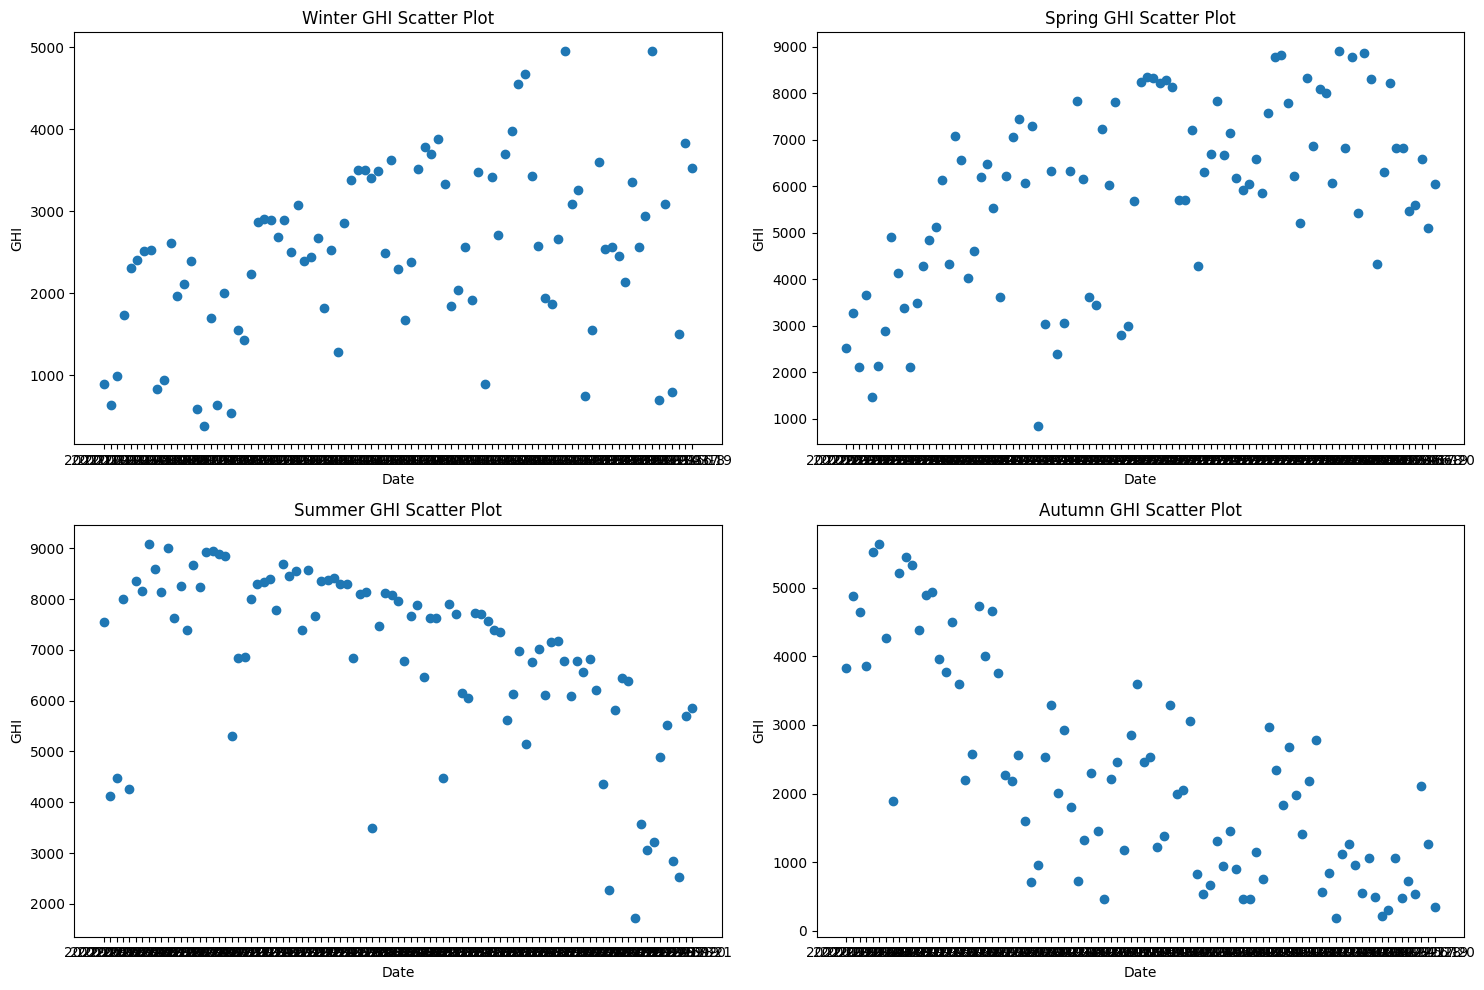

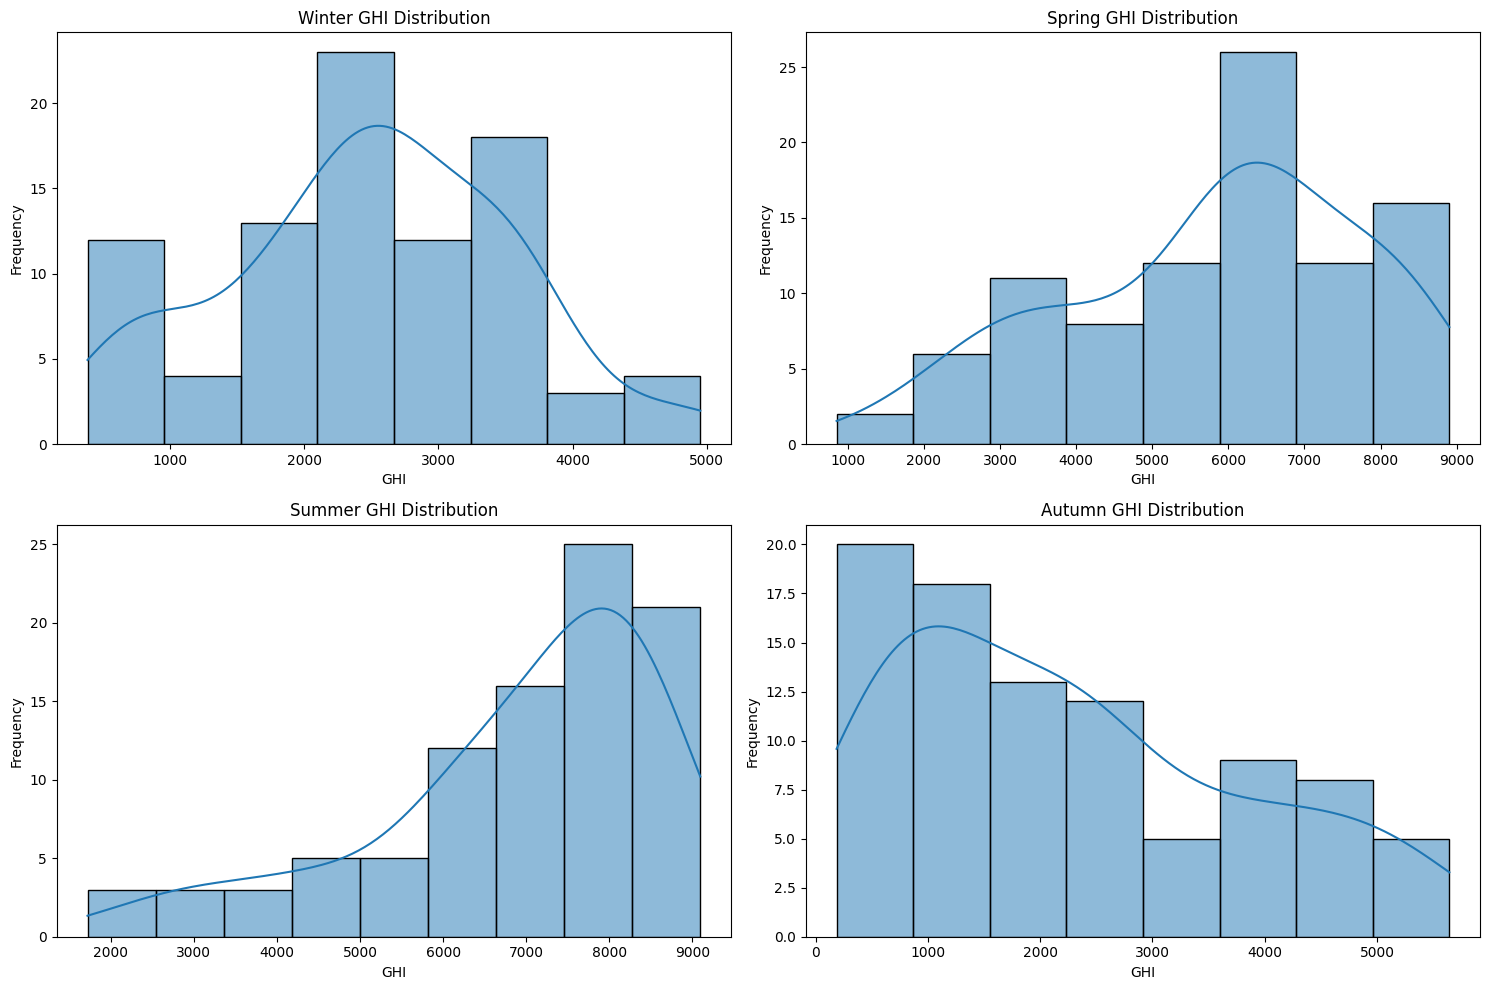

In [ ]:


# Scatter plots for each season
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(winter_df['Date'], winter_df['GHI'])
plt.title('Winter GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.subplot(2, 2, 2)
plt.scatter(spring_df['Date'], spring_df['GHI'])
plt.title('Spring GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.subplot(2, 2, 3)
plt.scatter(summer_df['Date'], summer_df['GHI'])
plt.title('Summer GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.subplot(2, 2, 4)
plt.scatter(autumn_df['Date'], autumn_df['GHI'])
plt.title('Autumn GHI Scatter Plot')
plt.xlabel('Date')
plt.ylabel('GHI')

plt.tight_layout()
plt.show()

# Distribution plots for each season
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(winter_df['GHI'], kde=True)
plt.title('Winter GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.histplot(spring_df['GHI'], kde=True)
plt.title('Spring GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(summer_df['GHI'], kde=True)
plt.title('Summer GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.subplot(2, 2, 4)
sns.histplot(autumn_df['GHI'], kde=True)
plt.title('Autumn GHI Distribution')
plt.xlabel('GHI')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

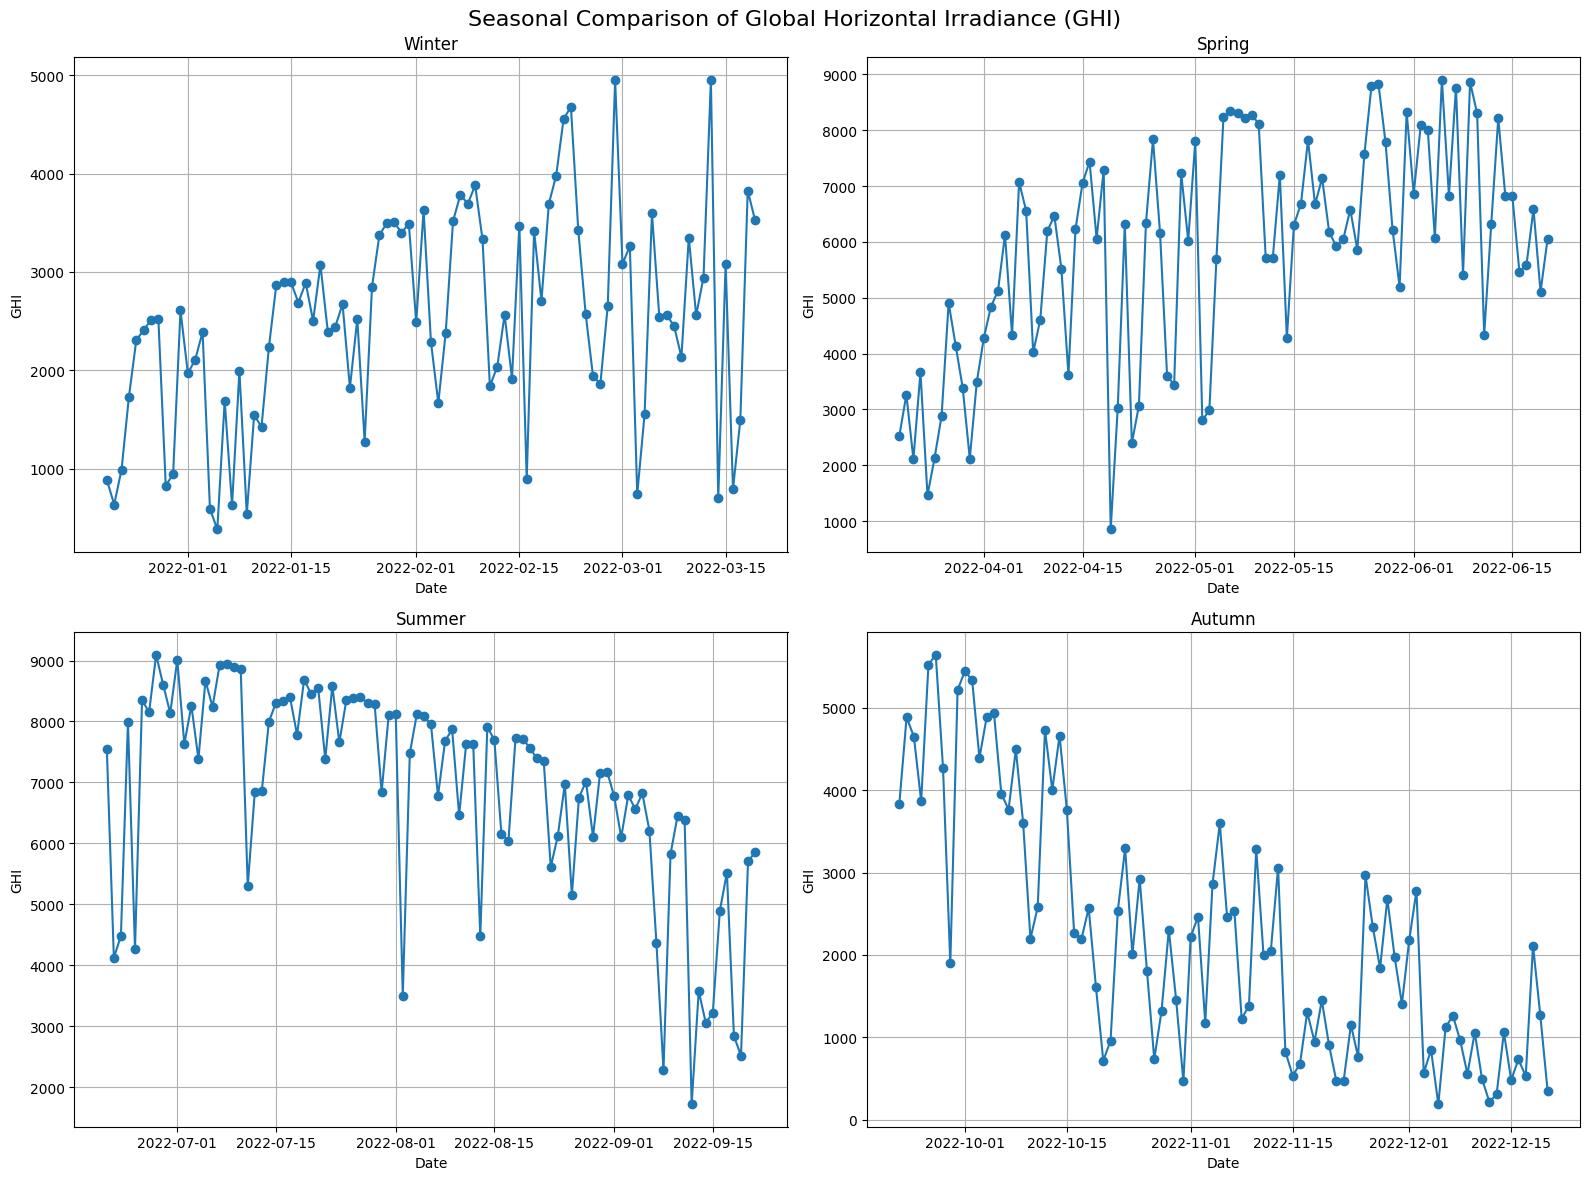

In [110]:

seasonal_dfs = {
    'Winter': winter_df,
    'Spring': spring_df,
    'Summer': summer_df,
    'Autumn': autumn_df
}

fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()

plt.suptitle('Seasonal Comparison of Global Horizontal Irradiance (GHI)', fontsize=16)
for ax, (season_name, df) in zip(axes, seasonal_dfs.items()):

    ax.plot(df.index, df['GHI'], marker='o', linewidth=1.5)
    ax.set_title(f'{season_name}')
    ax.set_xlabel('Date')
    ax.set_ylabel('GHI')
    ax.grid(True)



plt.tight_layout()
plt.show()

In [125]:

seasonal_dfs = {'Winter': winter_df, 'Spring': spring_df, 'Summer': summer_df, 'Autumn': autumn_df}

for season_name, df in seasonal_dfs.items():
    print(f"\n--- Performing ADF Test for {season_name} ---")
    result = adfuller(df['GHI'].dropna()) # Drop NA values to avoid errors if any
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if result[1] <= 0.05:
        print(f"Conclusion: The time series for {season_name} is likely stationary (p-value <= 0.05).")
    else:
        print(f"Conclusion: The time series for {season_name} is likely non-stationary (p-value > 0.05).")


--- Performing ADF Test for Winter ---
ADF Statistic: -2.937327
p-value: 0.041176
Critical Values:
	1%: -3.511
	5%: -2.897
	10%: -2.585
Conclusion: The time series for Winter is likely stationary (p-value <= 0.05).

--- Performing ADF Test for Spring ---
ADF Statistic: -5.442697
p-value: 0.000003
Critical Values:
	1%: -3.504
	5%: -2.894
	10%: -2.584
Conclusion: The time series for Spring is likely stationary (p-value <= 0.05).

--- Performing ADF Test for Summer ---
ADF Statistic: 0.051340
p-value: 0.962577
Critical Values:
	1%: -3.514
	5%: -2.898
	10%: -2.586
Conclusion: The time series for Summer is likely non-stationary (p-value > 0.05).

--- Performing ADF Test for Autumn ---
ADF Statistic: -2.046828
p-value: 0.266425
Critical Values:
	1%: -3.508
	5%: -2.895
	10%: -2.585
Conclusion: The time series for Autumn is likely non-stationary (p-value > 0.05).


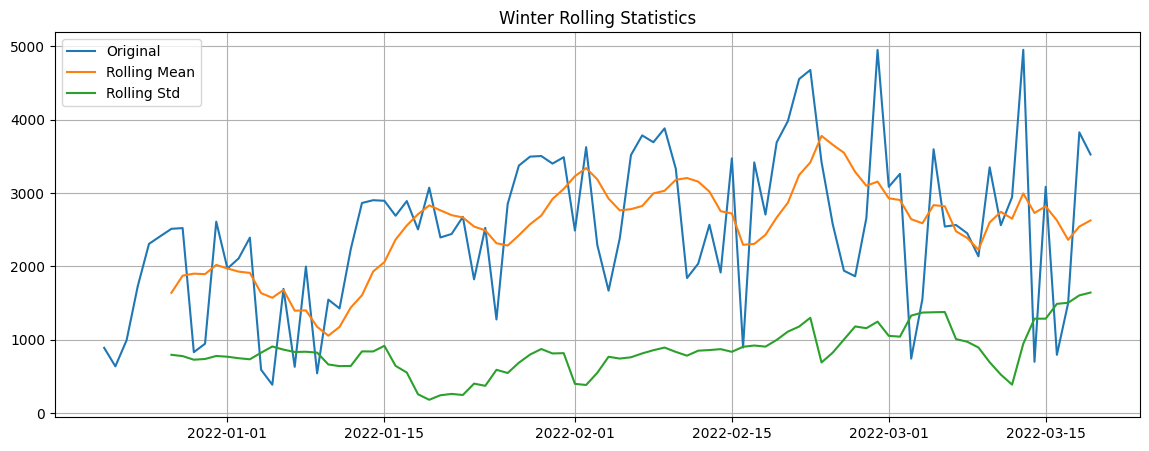

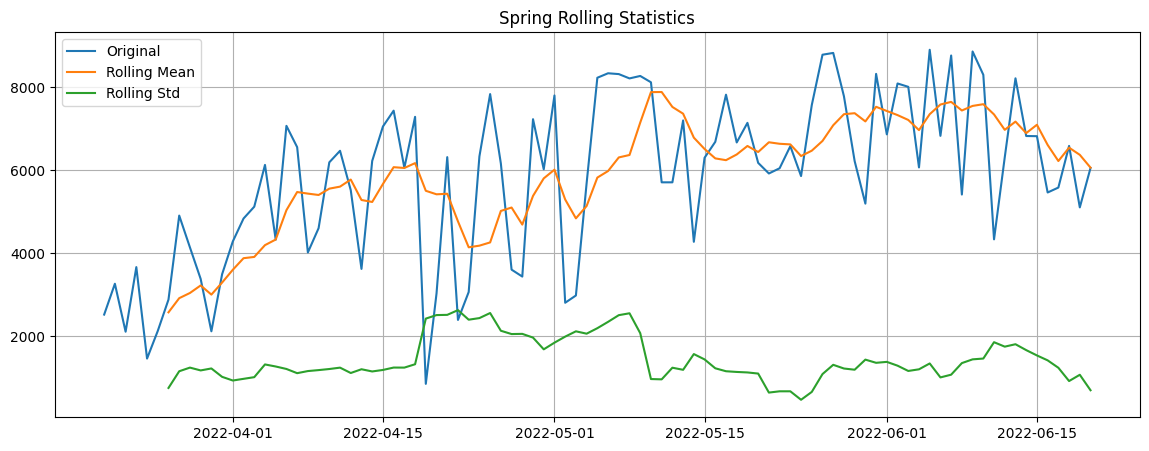

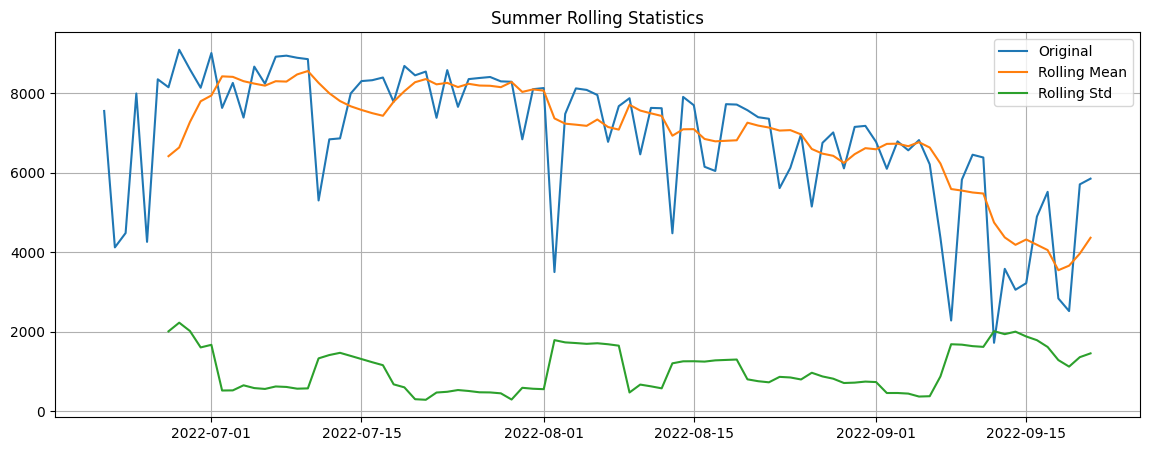

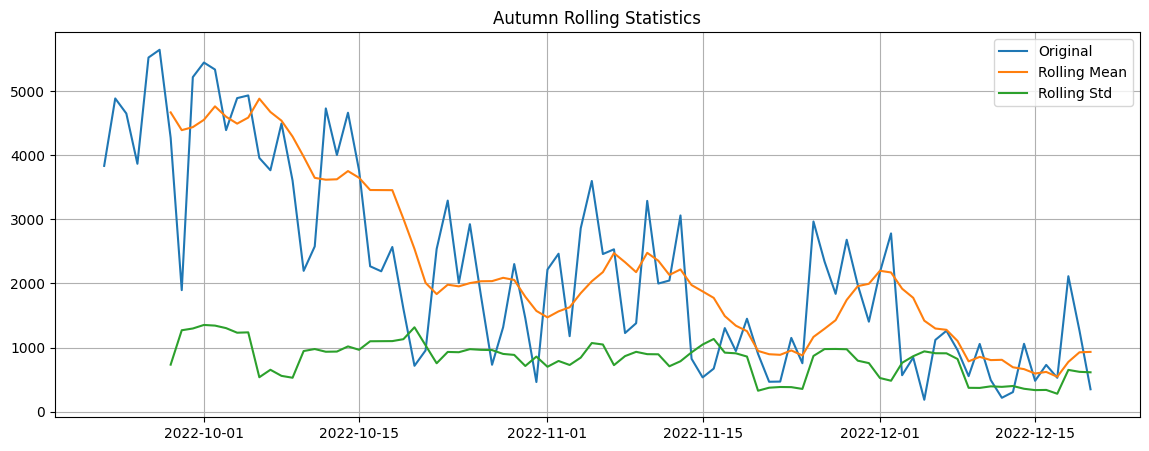

In [122]:
seasonal_dfs = {
    'Winter': winter_df,
    'Spring': spring_df,
    'Summer': summer_df,
    'Autumn': autumn_df
}
for season_name, df in seasonal_dfs.items():
    fig, axes = plt.subplots(1, figsize=(14, 5))
    rolling_mean = df['GHI'].rolling(window=7).mean()
    rolling_std = df['GHI'].rolling(window=7).std()
    plt.plot(df.index, df['GHI'], label=''+'Original')
    plt.plot(df.index, rolling_mean, label='Rolling Mean')
    plt.plot(df.index, rolling_std, label='Rolling Std')

    plt.legend()
    plt.title(f'{season_name} Rolling Statistics')
    plt.grid(True)

    plt.show()

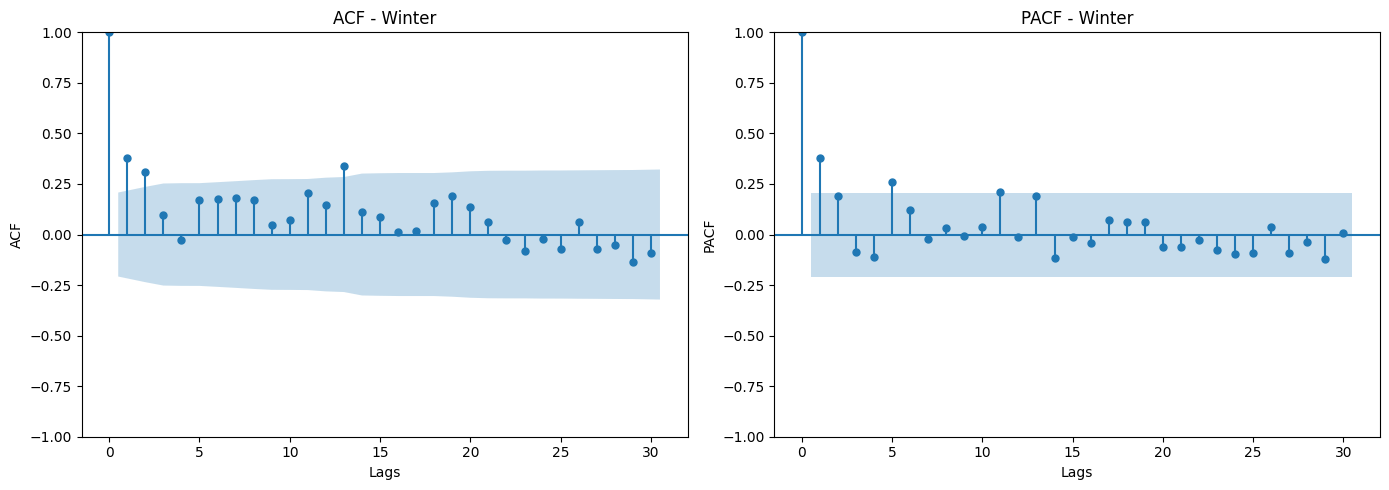

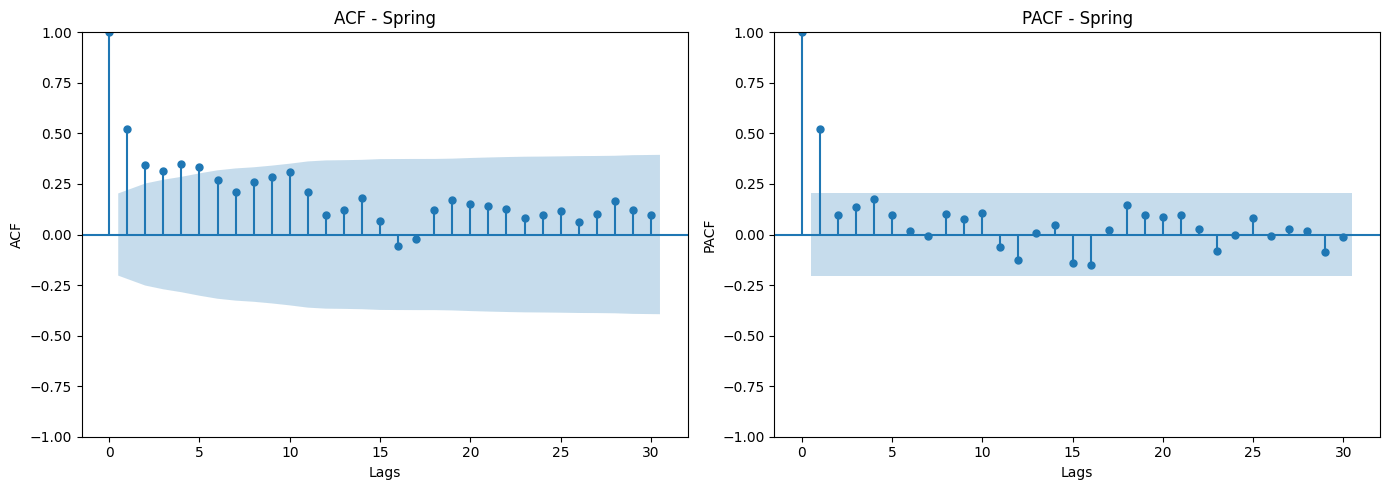

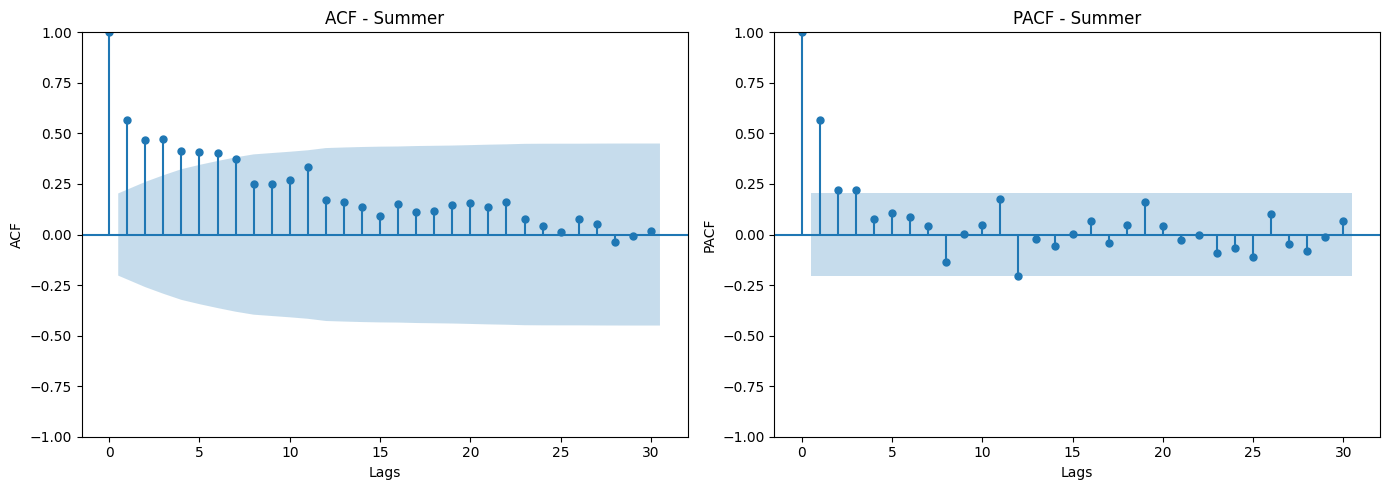

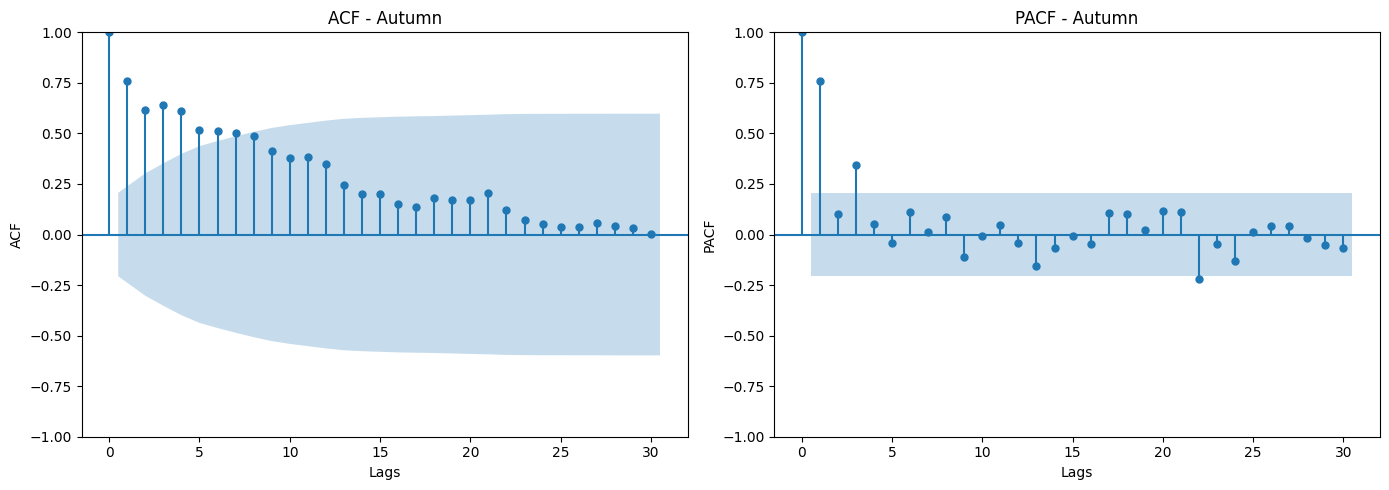

In [124]:
seasonal_dfs = {'Winter': winter_df, 'Spring': spring_df, 'Summer': summer_df, 'Autumn': autumn_df}

for season_name, df in seasonal_dfs.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_acf(df['GHI'], lags=30, ax=axes[0])
    axes[0].set_title(f'ACF - {season_name}')
    axes[0].set_xlabel('Lags')
    axes[0].set_ylabel('ACF')

    plot_pacf(df['GHI'], lags=30, ax=axes[1])
    axes[1].set_title(f'PACF - {season_name}')
    axes[1].set_xlabel('Lags')
    axes[1].set_ylabel('PACF')

    plt.tight_layout()
    plt.show()

In [90]:
print(winter_df.head)

             GHI
Date            
2021-12-21   890
2021-12-22   638
2021-12-23   993
2021-12-24  1732
2021-12-25  2307


### MAE and RMSE Comparison Plots

In [134]:
def evaluate_and_plot_model(df, name="Season", arima_order=(2,1,1), sarima_order=(2,1,1), sarima_seasonal_order=(1,0,1,7)):
    # Split data into training and testing sets
    train_size = int(len(df) * 0.8)
    train, test = df.iloc[:train_size], df.iloc[train_size:]

    # ARIMA Model
    try:
        arima_model = ARIMA(train['GHI'], order=arima_order)
        arima_model_fit = arima_model.fit()
        arima_predictions = arima_model_fit.predict(start=len(train), end=len(df)-1)

        # Calculate ARIMA metrics
        arima_aic = arima_model_fit.aic
        arima_bic = arima_model_fit.bic
        arima_mae = mean_absolute_error(test['GHI'], arima_predictions)
        arima_rmse = sqrt(mean_squared_error(test['GHI'], arima_predictions))

        # Plot ARIMA results
        plt.figure(figsize=(14, 6))
        plt.plot(test['GHI'].index, test['GHI'], marker='o',label='Actual GHI')
        plt.plot(arima_predictions.index, arima_predictions,marker='o' ,color='red', label='ARIMA Predicted GHI')
        plt.title(f'ARIMA Model: Actual vs. Predicted GHI for {name}')
        plt.xlabel('Date')
        plt.ylabel('GHI')
        plt.legend()
        plt.show()

        plt.figure(figsize=(14, 6))
        arima_residuals = test['GHI'] - arima_predictions
        plt.plot(arima_residuals.index, arima_residuals, marker='o',label='ARIMA Residuals')
        plt.axhline(0, color='gray', linestyle='--')
        plt.title(f'ARIMA Model: Residuals Plot for {name}')
        plt.xlabel('Date')
        plt.ylabel('Residual')
        plt.legend()
        plt.show()

        print(f"ARIMA Model Metrics for {name}:")
        print(f"  AIC: {arima_aic:.2f}")
        print(f"  BIC: {arima_bic:.2f}")
        print(f"  MAE: {arima_mae:.2f}")
        print(f"  RMSE: {arima_rmse:.2f}")
    except Exception as e:
        print(f"ARIMA model for {name} failed: {e}")
        arima_aic, arima_bic, arima_mae, arima_rmse = np.nan, np.nan, np.nan, np.nan

    print("\n" + "-"*30 + "\n")

    # SARIMA Model
    try:
        sarima_model = SARIMAX(train['GHI'], order=sarima_order, seasonal_order=sarima_seasonal_order)
        sarima_model_fit = sarima_model.fit(disp=False)
        sarima_predictions = sarima_model_fit.predict(start=len(train), end=len(df)-1)

        # Calculate SARIMA metrics
        sarima_aic = sarima_model_fit.aic
        sarima_bic = sarima_model_fit.bic
        sarima_mae = mean_absolute_error(test['GHI'], sarima_predictions)
        sarima_rmse = sqrt(mean_squared_error(test['GHI'], sarima_predictions))

        # Plot SARIMA results
        plt.figure(figsize=(14, 6))
        plt.plot(test['GHI'].index, test['GHI'],marker='o' ,label='Actual GHI')
        plt.plot(sarima_predictions.index, sarima_predictions, marker='o',color='green', label='SARIMA Predicted GHI')
        plt.title(f'SARIMA Model: Actual vs. Predicted GHI for {name}')
        plt.xlabel('Date')
        plt.ylabel('GHI')
        plt.legend()
        plt.show()

        plt.figure(figsize=(14, 6))
        sarima_residuals = test['GHI'] - sarima_predictions
        plt.plot(sarima_residuals.index, sarima_residuals, marker='o',label='SARIMA Residuals')
        plt.axhline(0, color='gray', linestyle='--')
        plt.title(f'SARIMA Model: Residuals Plot for {name}')
        plt.xlabel('Date')
        plt.ylabel('Residual')
        plt.legend()
        plt.show()

        print(f"SARIMA Model Metrics for {name}:")
        print(f"  AIC: {sarima_aic:.2f}")
        print(f"  BIC: {sarima_bic:.2f}")
        print(f"  MAE: {sarima_mae:.2f}")
        print(f"  RMSE: {sarima_rmse:.2f}")
    except Exception as e:
        print(f"SARIMA model for {name} failed: {e}")
        sarima_aic, sarima_bic, sarima_mae, sarima_rmse = np.nan, np.nan, np.nan, np.nan

    return {
        'ARIMA_AIC': arima_aic,
        'ARIMA_BIC': arima_bic,
        'ARIMA_MAE': arima_mae,
        'ARIMA_RMSE': arima_rmse,
        'SARIMA_AIC': sarima_aic,
        'SARIMA_BIC': sarima_bic,
        'SARIMA_MAE': sarima_mae,
        'SARIMA_RMSE': sarima_rmse
    }


--- Evaluating Winter Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

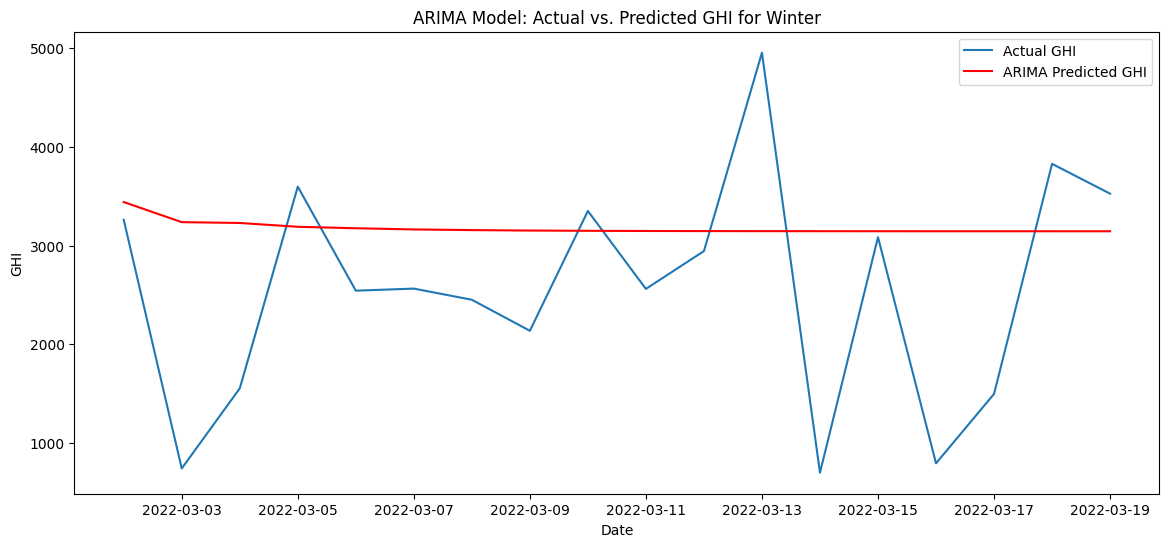

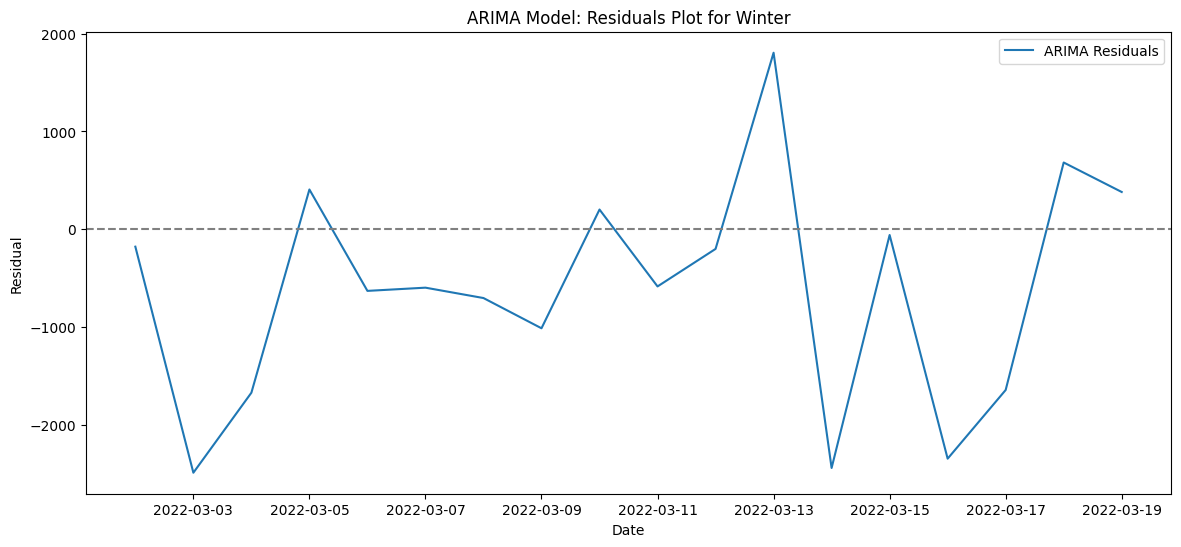

ARIMA Model Metrics for Winter:
  AIC: 1149.07
  BIC: 1158.06
  MAE: 1003.60
  RMSE: 1291.39

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

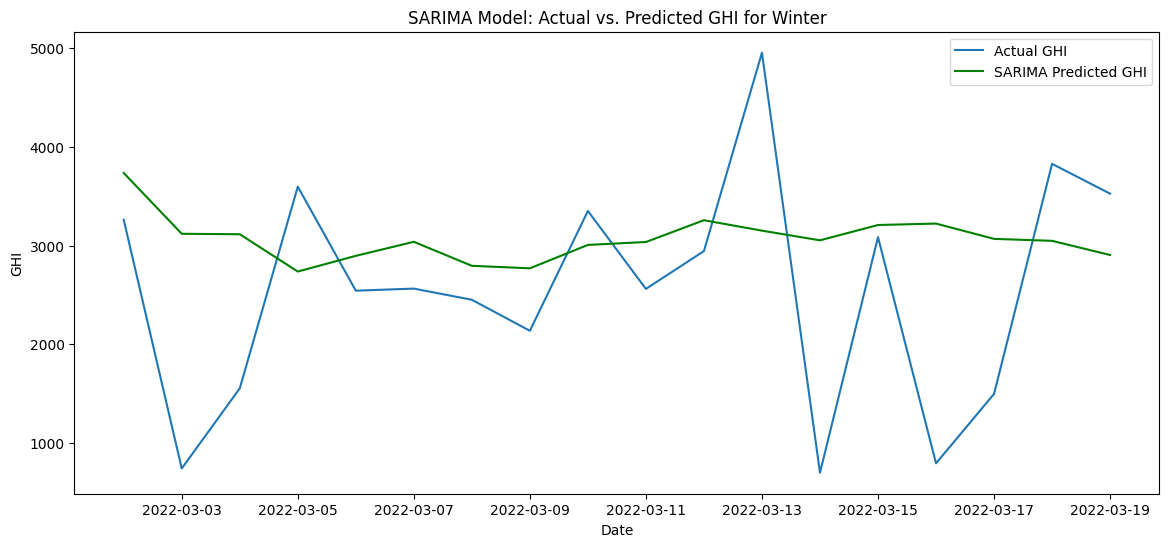

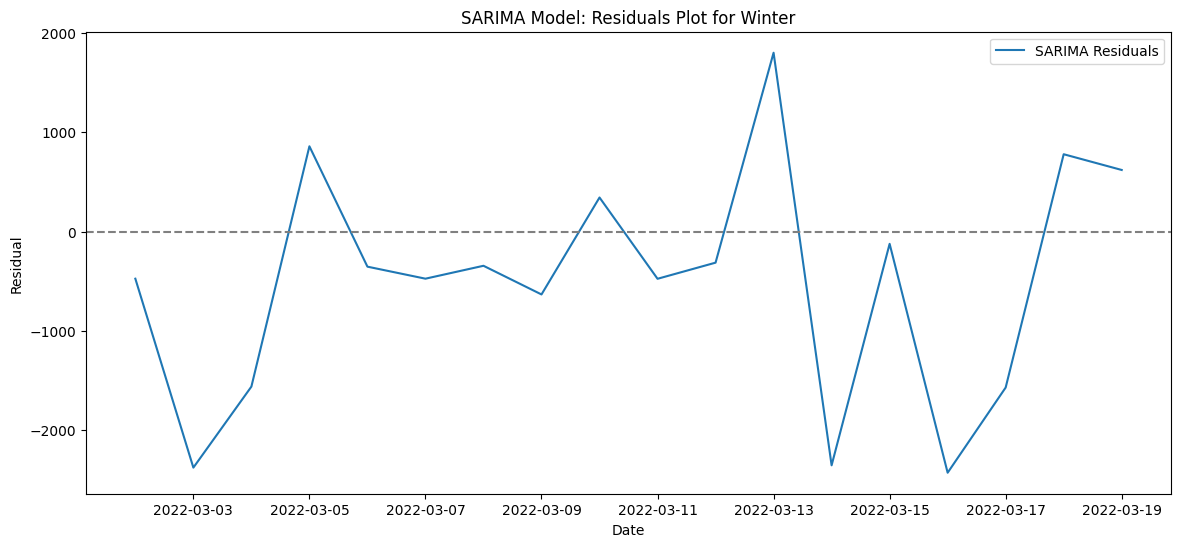

SARIMA Model Metrics for Winter:
  AIC: 1151.08
  BIC: 1164.57
  MAE: 993.13
  RMSE: 1258.16

--- Evaluating Spring Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


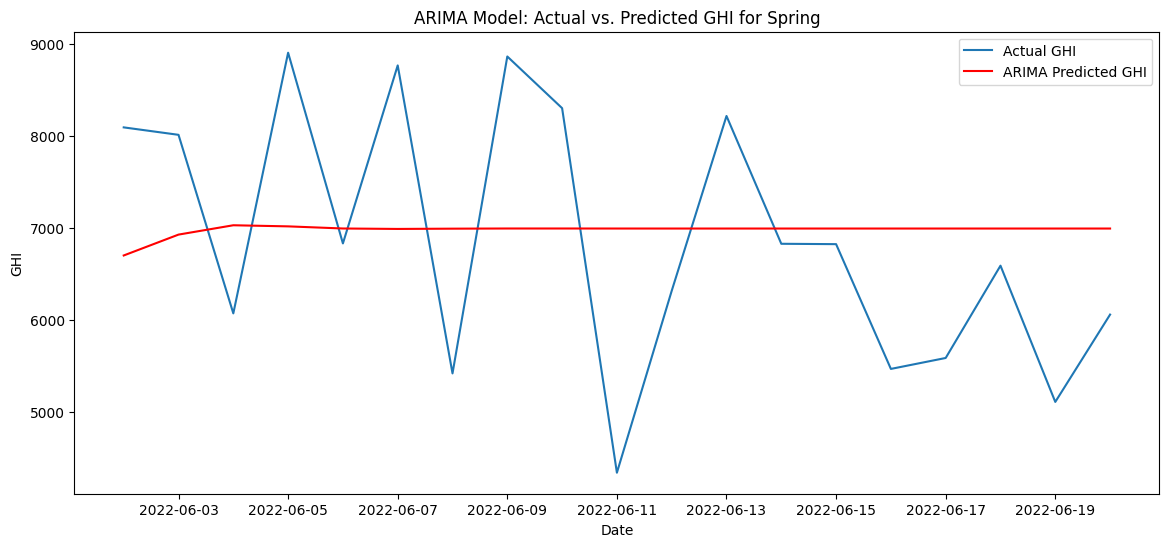

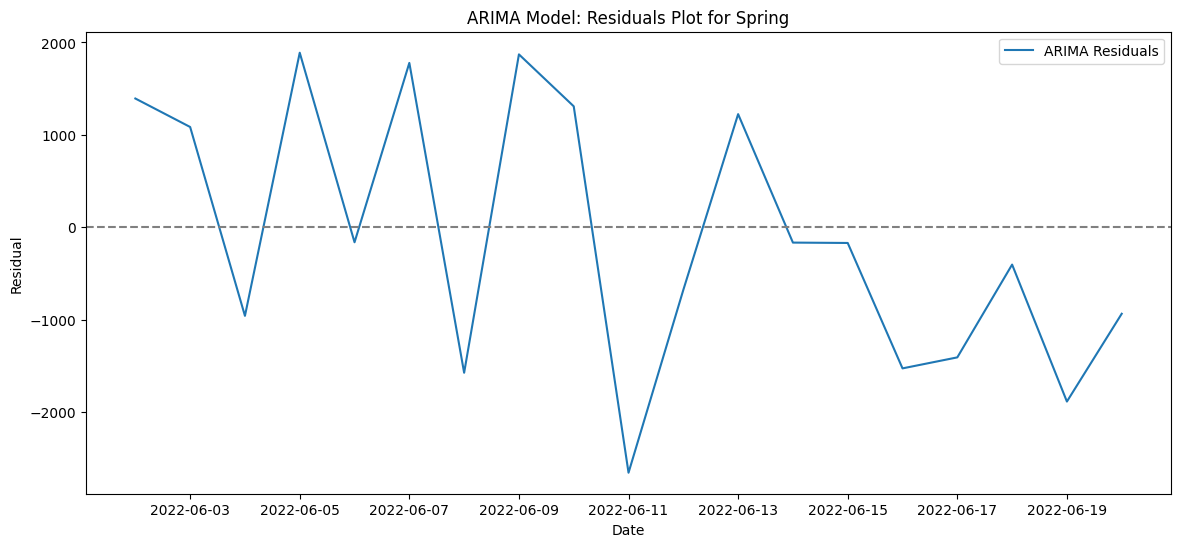

ARIMA Model Metrics for Spring:
  AIC: 1293.28
  BIC: 1302.44
  MAE: 1214.41
  RMSE: 1385.29

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


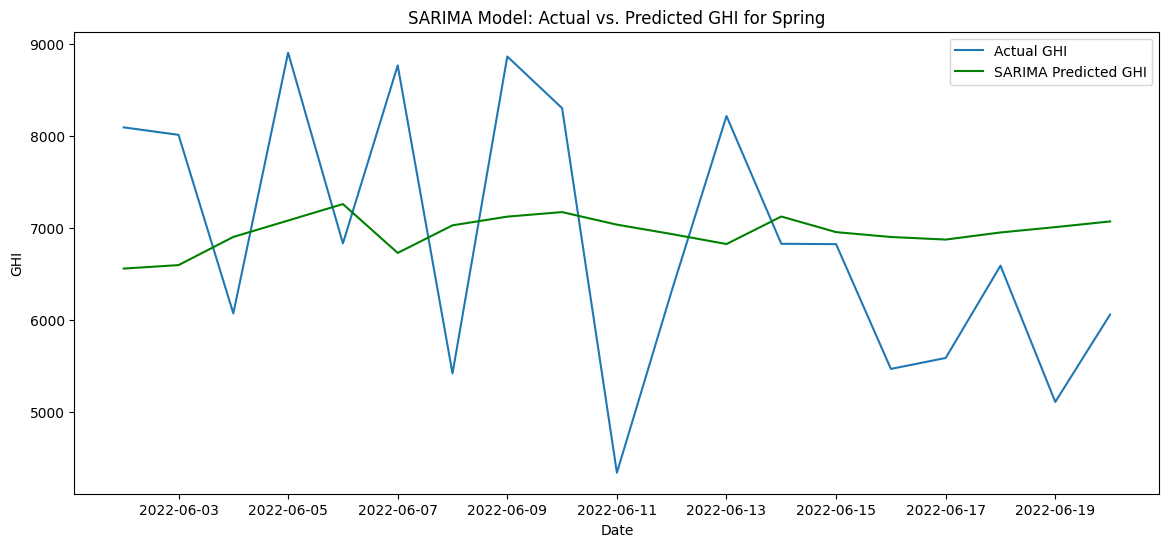

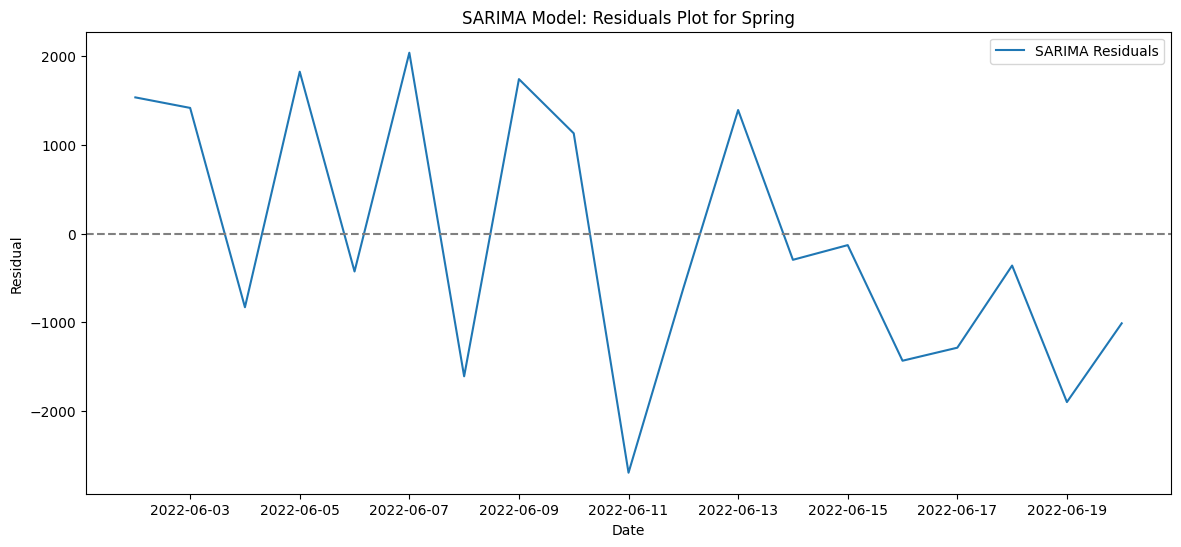

SARIMA Model Metrics for Spring:
  AIC: 1295.15
  BIC: 1308.90
  MAE: 1247.04
  RMSE: 1411.08

--- Evaluating Summer Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


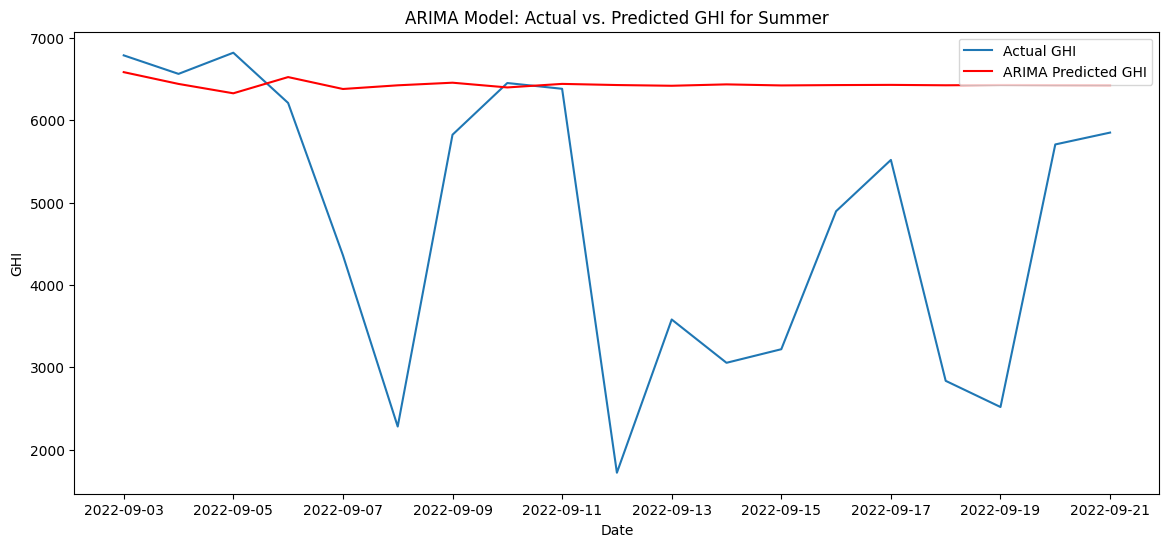

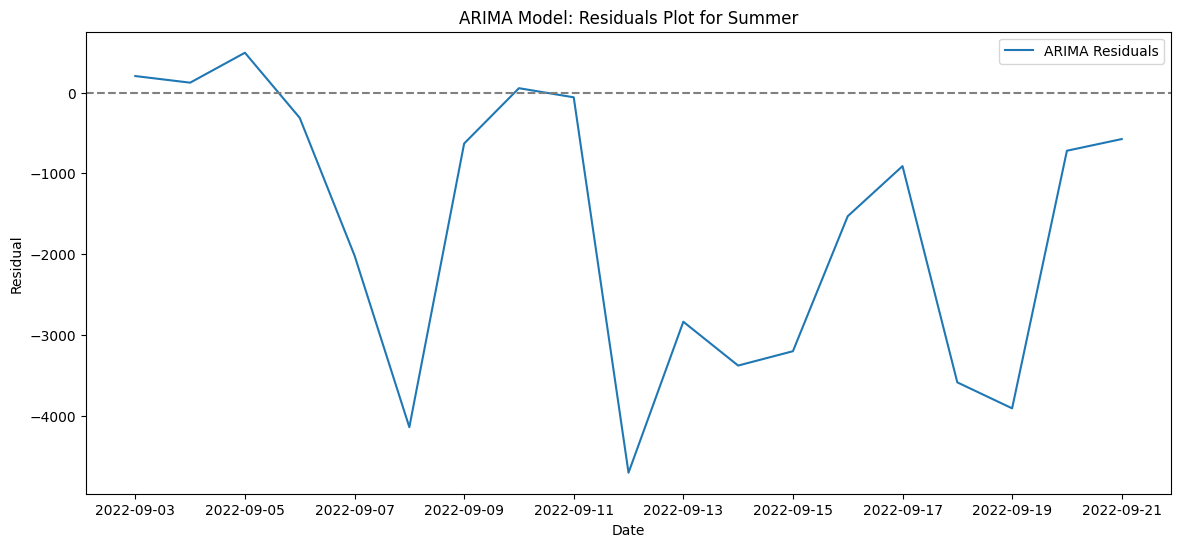

ARIMA Model Metrics for Summer:
  AIC: 1246.07
  BIC: 1255.24
  MAE: 1758.67
  RMSE: 2364.13

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


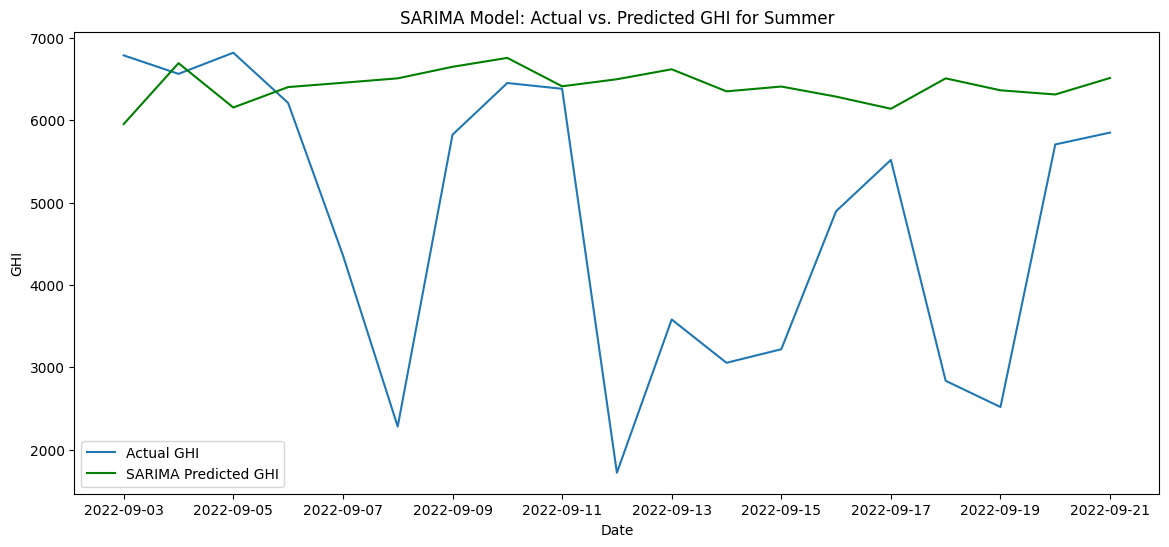

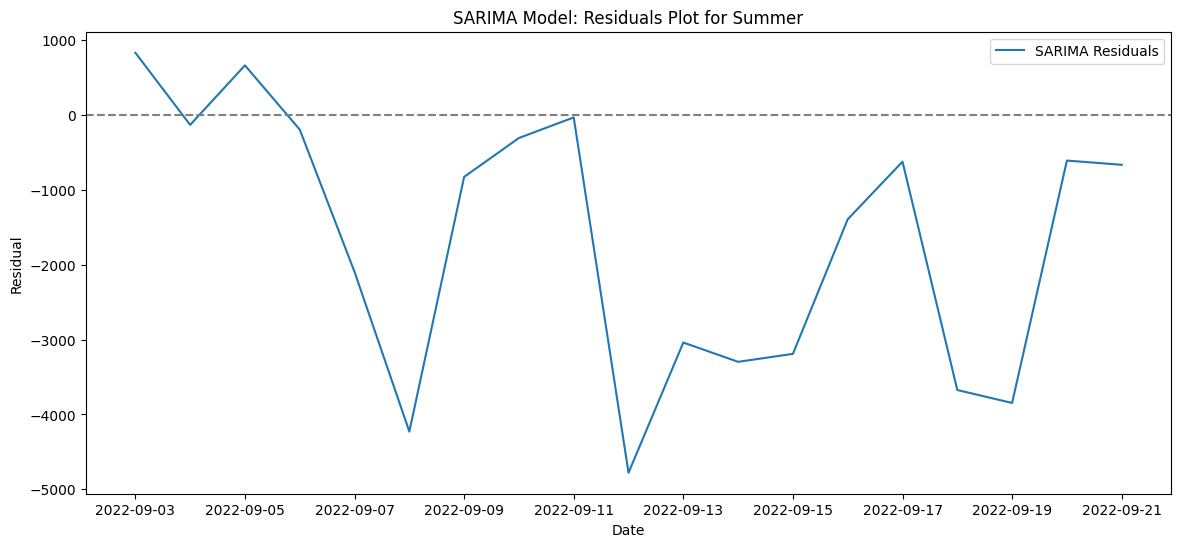

SARIMA Model Metrics for Summer:
  AIC: 1245.52
  BIC: 1259.26
  MAE: 1811.31
  RMSE: 2392.75

--- Evaluating Autumn Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


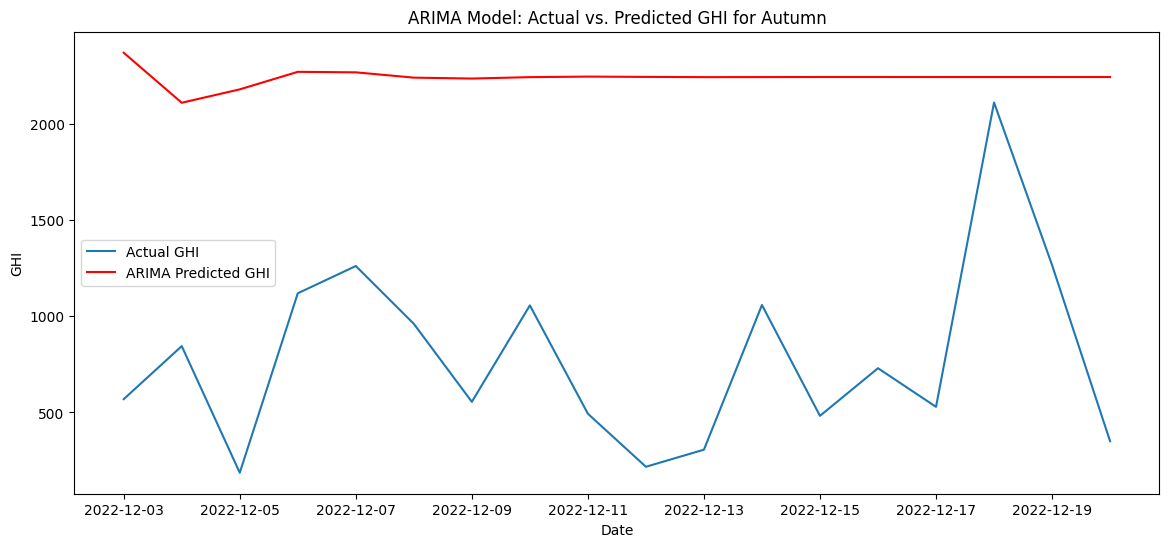

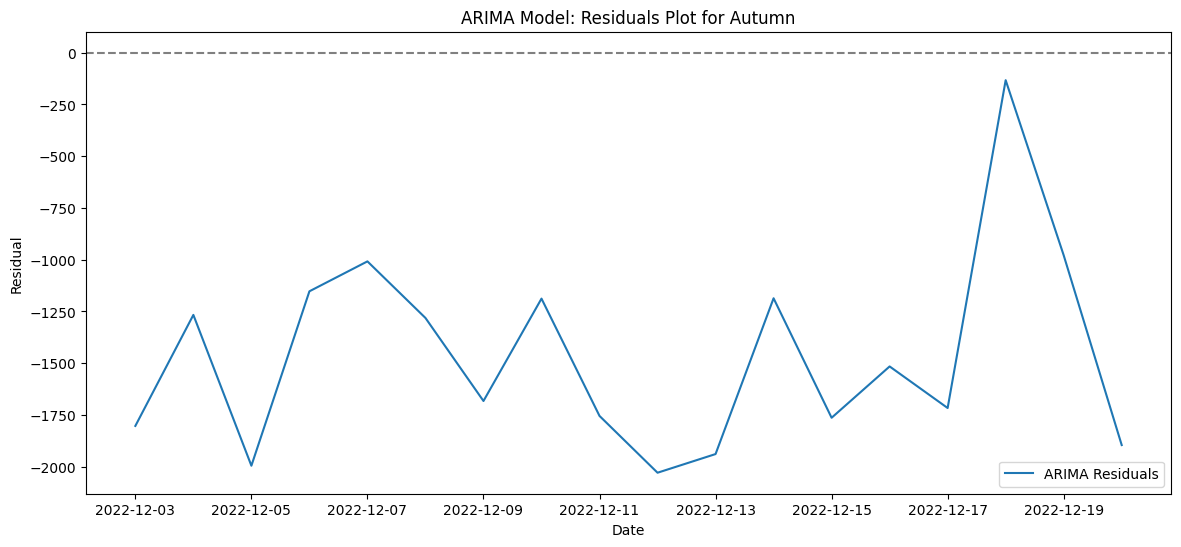

ARIMA Model Metrics for Autumn:
  AIC: 1183.68
  BIC: 1192.73
  MAE: 1460.68
  RMSE: 1534.07

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


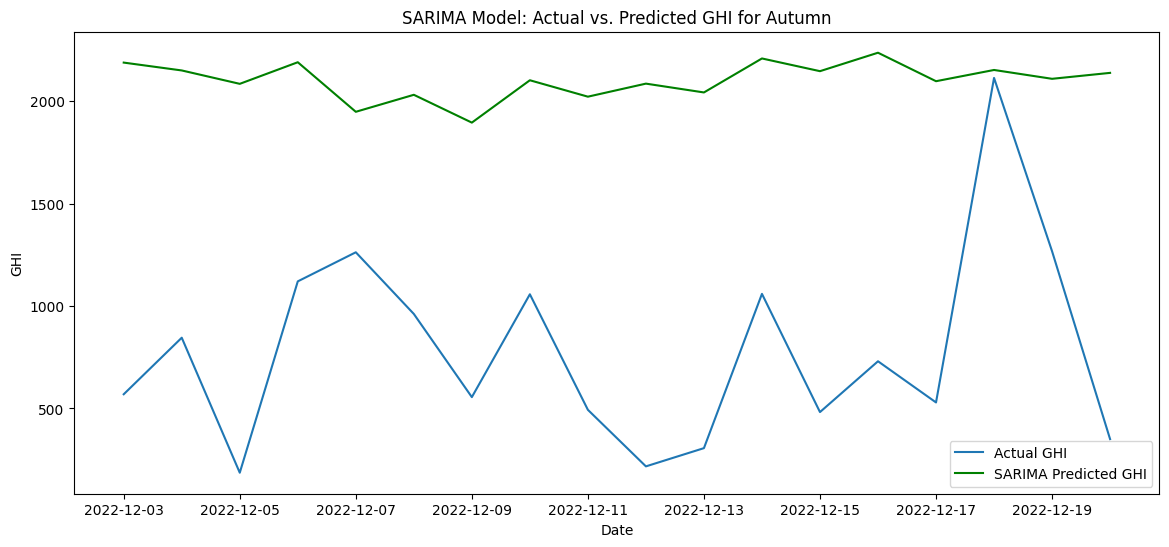

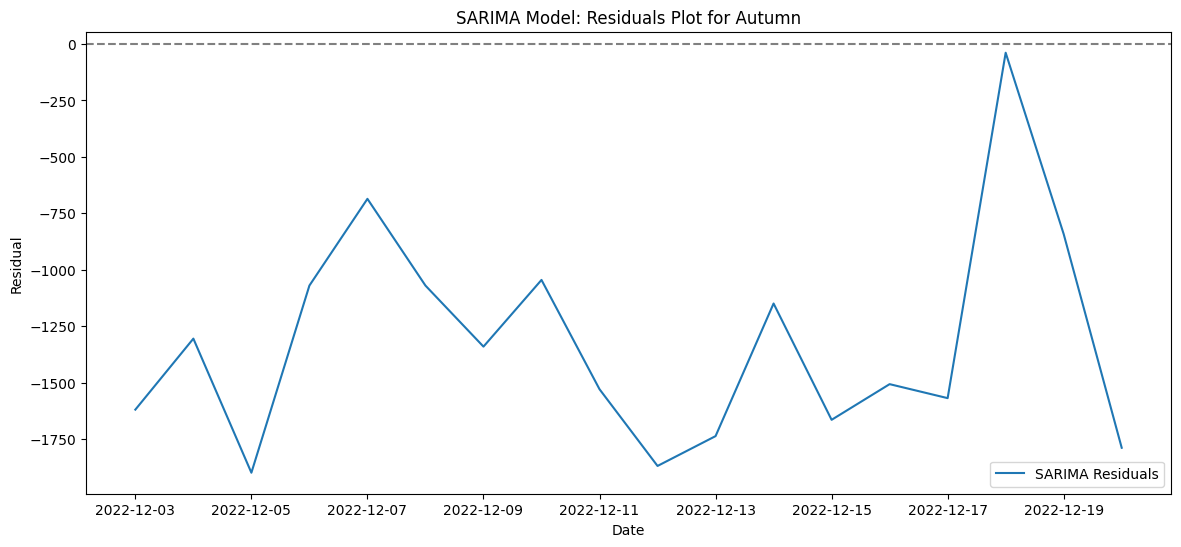

SARIMA Model Metrics for Autumn:
  AIC: 1184.95
  BIC: 1198.52
  MAE: 1317.73
  RMSE: 1397.07

--- Summary of Model Metrics ---
Winter Metrics: {'ARIMA_AIC': np.float64(1149.066377786053), 'ARIMA_BIC': np.float64(1158.0603587542505), 'ARIMA_MAE': 1003.603790704526, 'ARIMA_RMSE': 1291.3853575106548, 'SARIMA_AIC': np.float64(1151.0751056273132), 'SARIMA_BIC': np.float64(1164.5660770796094), 'SARIMA_MAE': 993.1301215970943, 'SARIMA_RMSE': 1258.1594112851228}
Spring Metrics: {'ARIMA_AIC': np.float64(1293.2801067669209), 'ARIMA_BIC': np.float64(1302.4419445315145), 'ARIMA_MAE': 1214.4113109321327, 'ARIMA_RMSE': 1385.2871291219305, 'SARIMA_AIC': np.float64(1295.1547369360035), 'SARIMA_BIC': np.float64(1308.8974935828937), 'SARIMA_MAE': 1247.0411709051386, 'SARIMA_RMSE': 1411.0826379253965}
Summer Metrics: {'ARIMA_AIC': np.float64(1246.0740979211093), 'ARIMA_BIC': np.float64(1255.235935685703), 'ARIMA_MAE': 1758.667325445269, 'ARIMA_RMSE': 2364.1272667920152, 'SARIMA_AIC': np.float64(1245.520

In [83]:
# # Define orders for each season based on ADF test and general time series characteristics
# # (p,d,q) for ARIMA and (P,D,Q,S) for seasonal part of SARIMA

# winter_arima_order = (2, 1, 1)
# winter_sarima_order = (2, 1, 1)
# winter_sarima_seasonal_order = (1, 0, 1, 7)

# spring_arima_order = (2, 0, 1)
# spring_sarima_order = (2, 0, 1)
# spring_sarima_seasonal_order = (1, 0, 1, 7)

# summer_arima_order = (2, 1, 1)
# summer_sarima_order = (2, 1, 1)
# summer_sarima_seasonal_order = (1, 0, 1, 7)

# autumn_arima_order = (2, 1, 1)
# autumn_sarima_order = (2, 1, 1)
# autumn_sarima_seasonal_order = (1, 0, 1, 7)

print("\n--- Evaluating Winter Data ---")
winter_metrics = evaluate_and_plot_model(winter_df, name="Winter", arima_order=winter_arima_order, sarima_order=winter_sarima_order, sarima_seasonal_order=winter_sarima_seasonal_order)

print("\n--- Evaluating Spring Data ---")
spring_metrics = evaluate_and_plot_model(spring_df, name="Spring", arima_order=spring_arima_order, sarima_order=spring_sarima_order, sarima_seasonal_order=spring_sarima_seasonal_order)

print("\n--- Evaluating Summer Data ---")
summer_metrics = evaluate_and_plot_model(summer_df, name="Summer", arima_order=summer_arima_order, sarima_order=summer_sarima_order, sarima_seasonal_order=summer_sarima_seasonal_order)

print("\n--- Evaluating Autumn Data ---")
autumn_metrics = evaluate_and_plot_model(autumn_df, name="Autumn", arima_order=autumn_arima_order, sarima_order=autumn_sarima_order, sarima_seasonal_order=autumn_sarima_seasonal_order)

print("\n--- Summary of Model Metrics ---")
print("Winter Metrics:", winter_metrics)
print("Spring Metrics:", spring_metrics)
print("Summer Metrics:", summer_metrics)
print("Autumn Metrics:", autumn_metrics)


--- Evaluating Winter Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

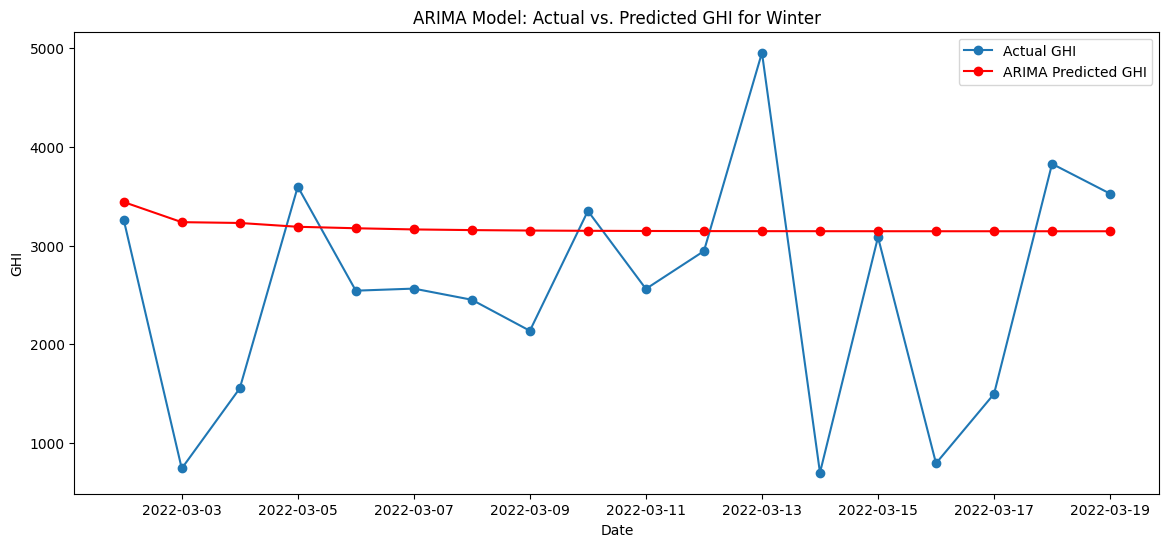

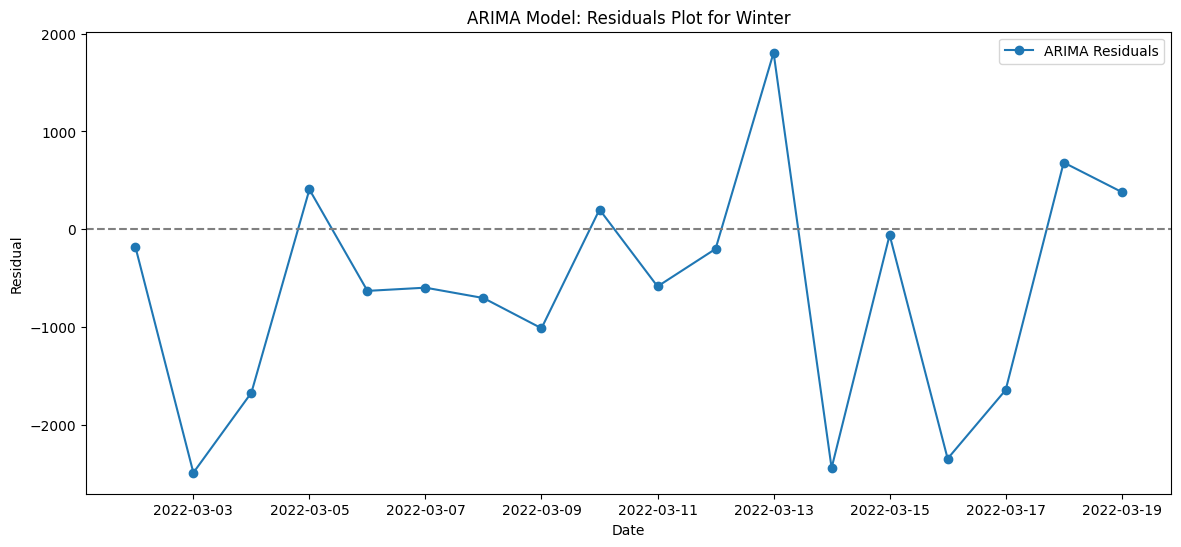

ARIMA Model Metrics for Winter:
  AIC: 1149.07
  BIC: 1158.06
  MAE: 1003.60
  RMSE: 1291.39

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimiz

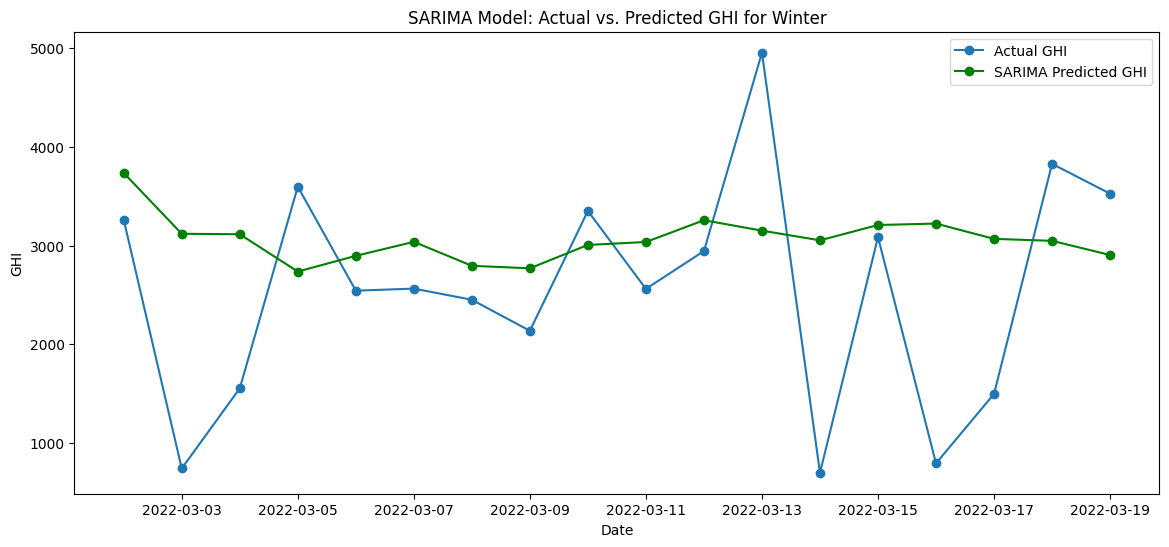

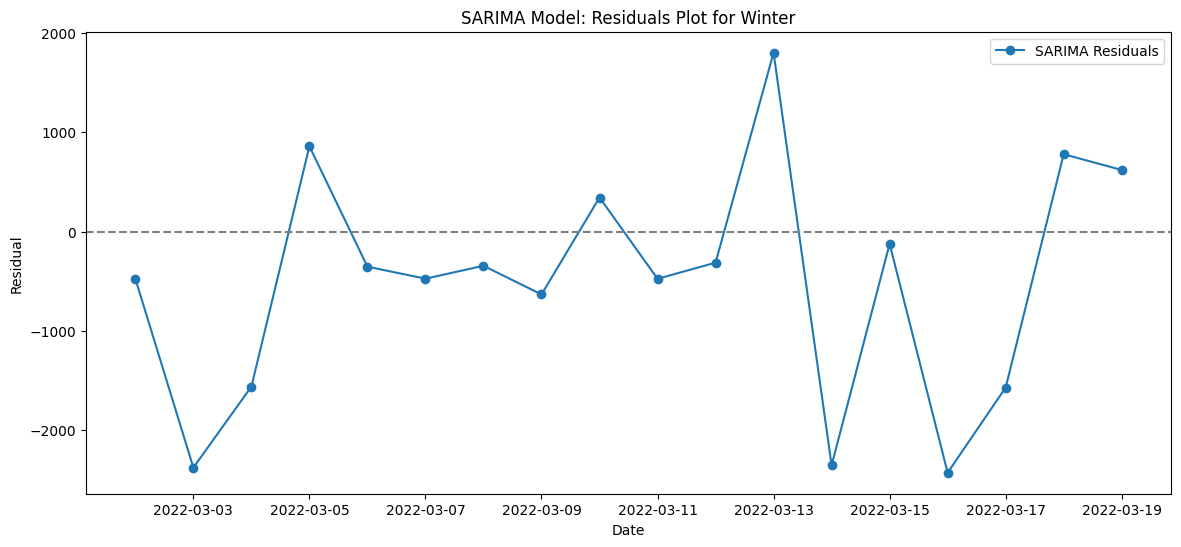

SARIMA Model Metrics for Winter:
  AIC: 1151.08
  BIC: 1164.57
  MAE: 993.13
  RMSE: 1258.16

--- Evaluating Spring Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

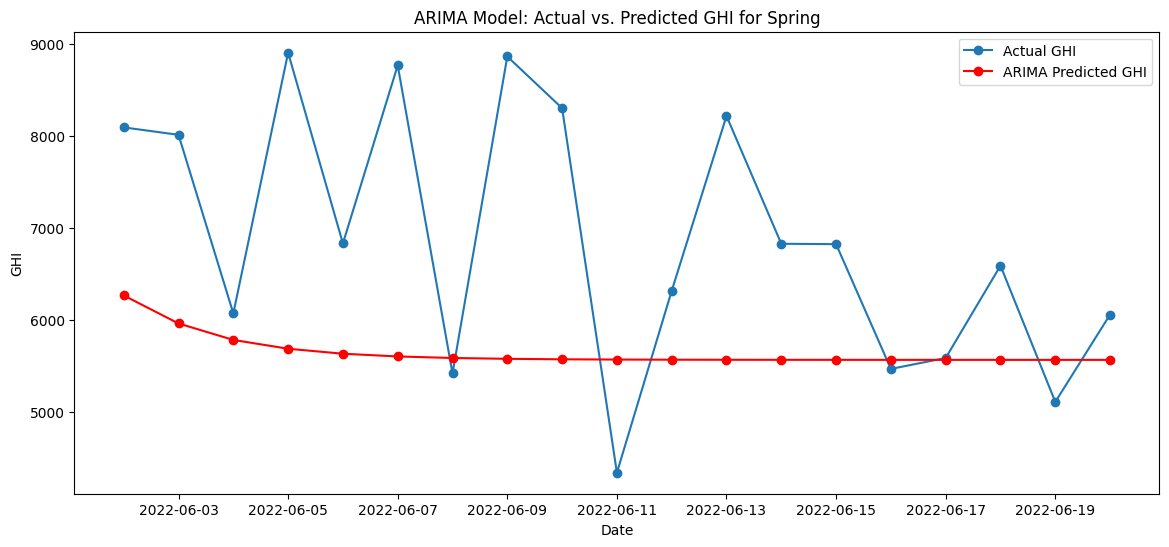

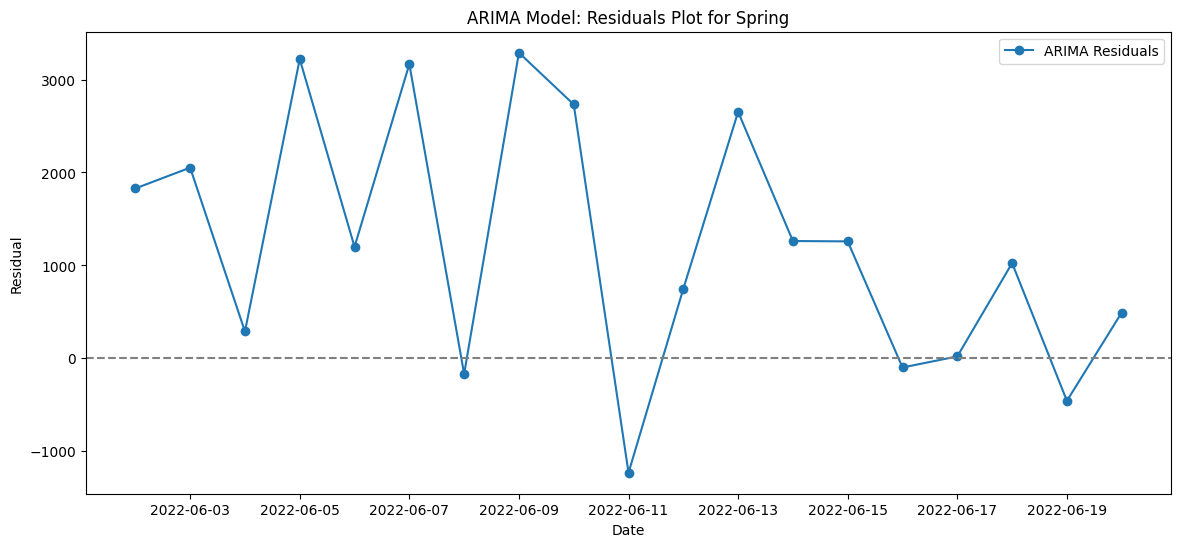

ARIMA Model Metrics for Spring:
  AIC: 1317.62
  BIC: 1329.14
  MAE: 1430.84
  RMSE: 1799.92

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starti

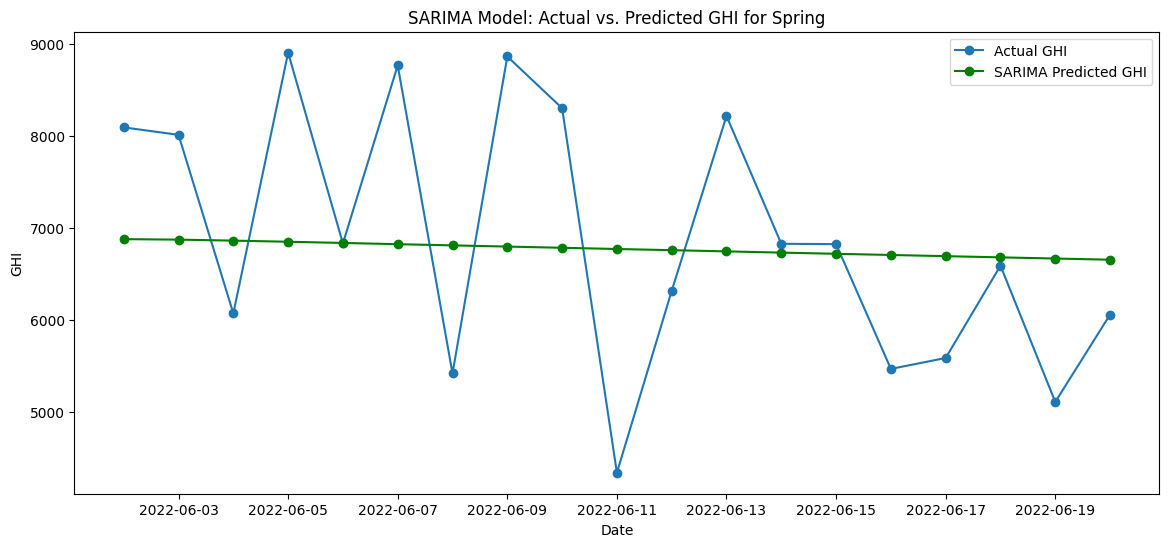

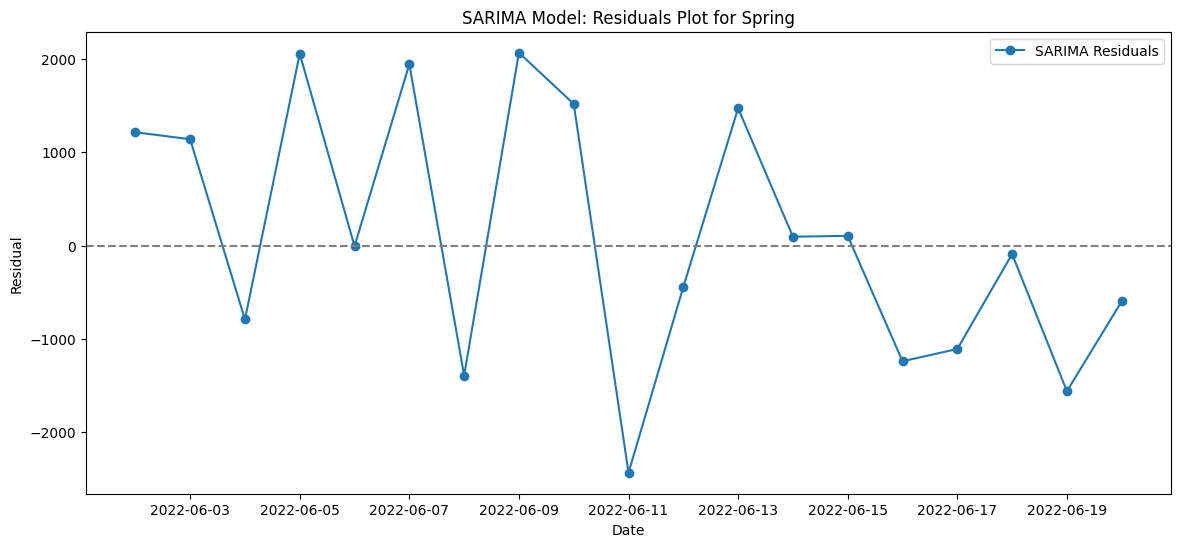

SARIMA Model Metrics for Spring:
  AIC: 1319.48
  BIC: 1333.31
  MAE: 1119.63
  RMSE: 1333.64

--- Evaluating Summer Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


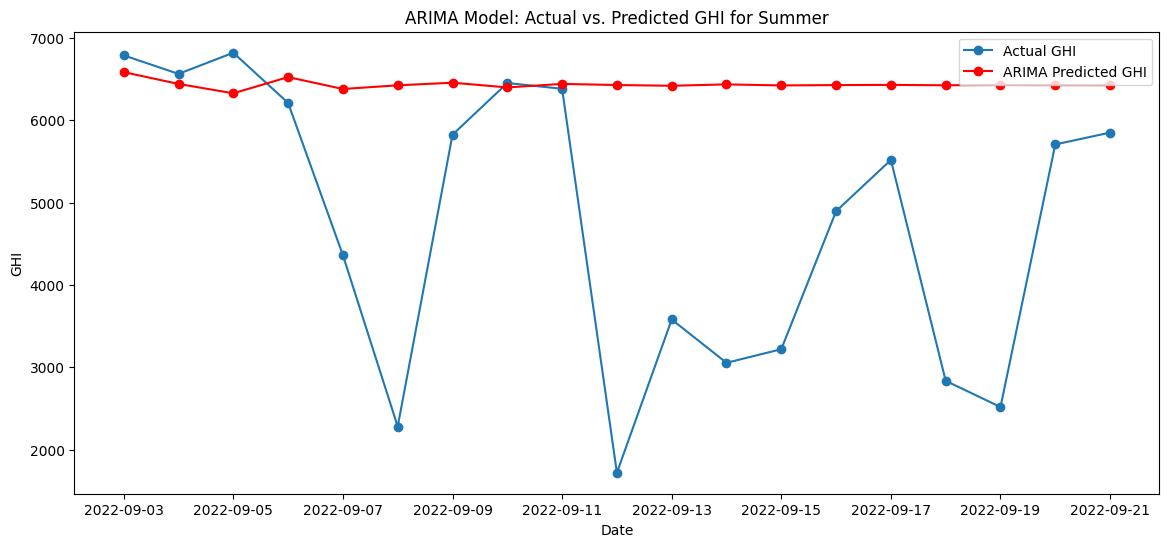

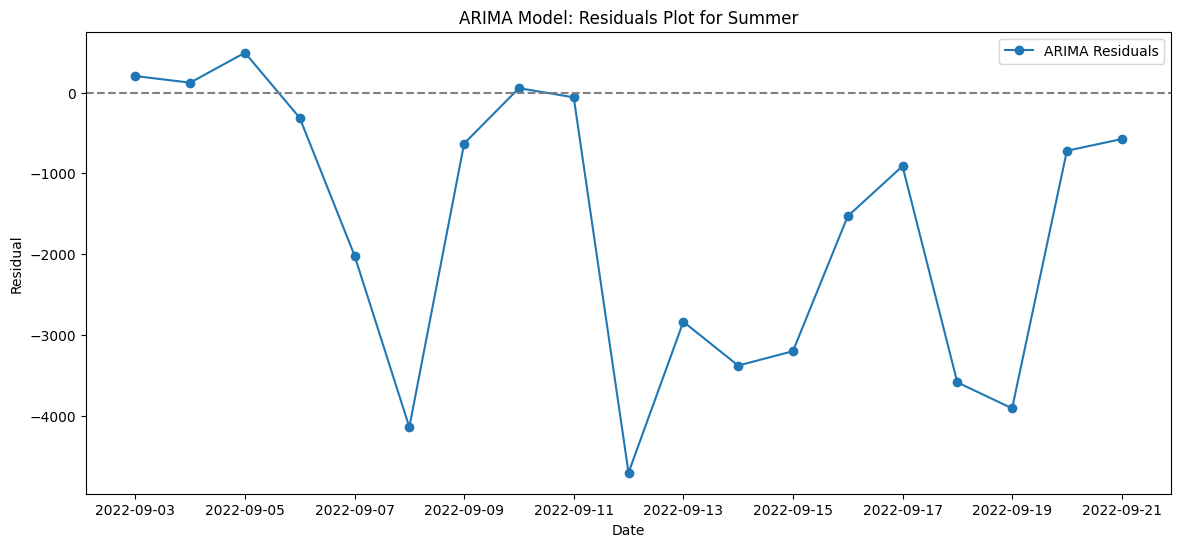

ARIMA Model Metrics for Summer:
  AIC: 1246.07
  BIC: 1255.24
  MAE: 1758.67
  RMSE: 2364.13

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


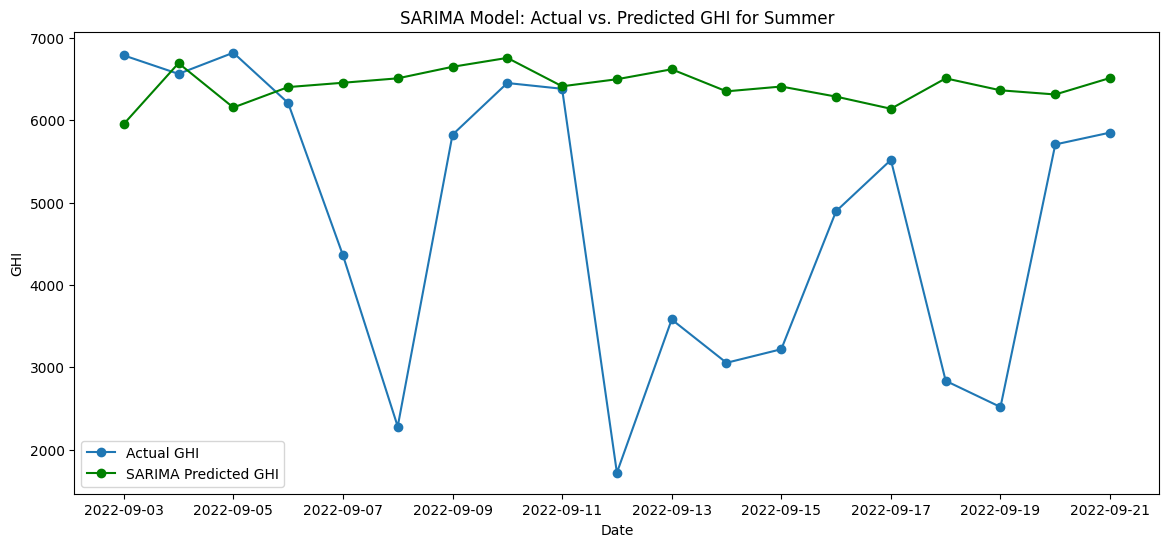

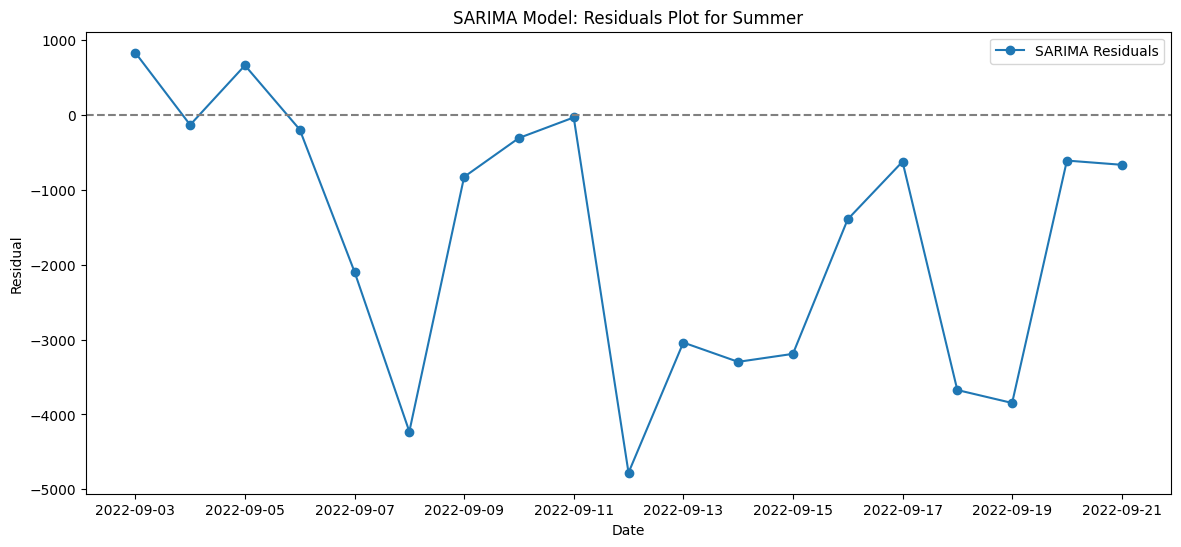

SARIMA Model Metrics for Summer:
  AIC: 1245.52
  BIC: 1259.26
  MAE: 1811.31
  RMSE: 2392.75

--- Evaluating Autumn Data ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


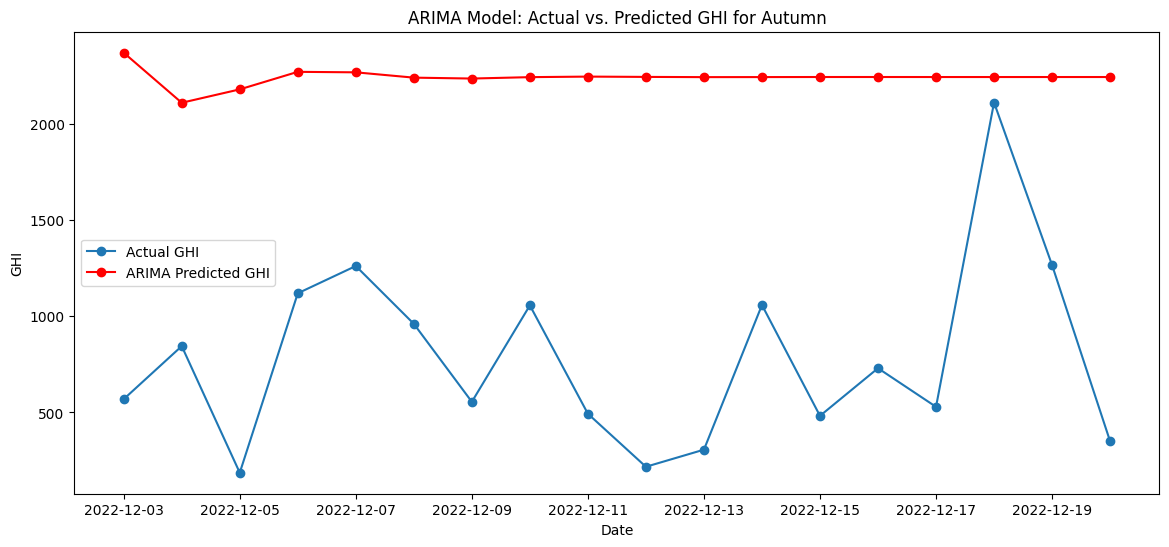

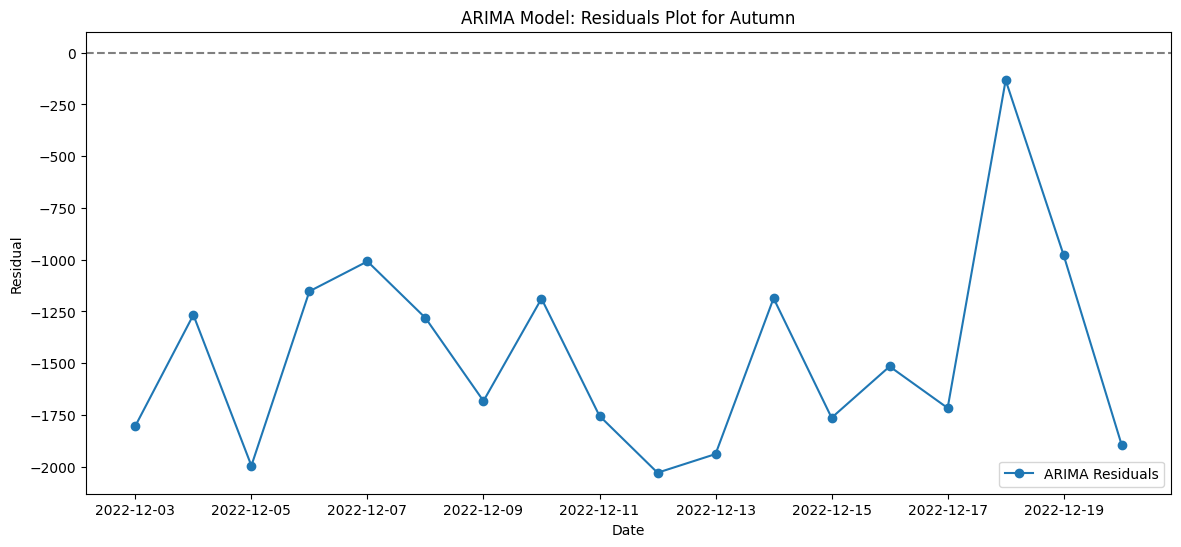

ARIMA Model Metrics for Autumn:
  AIC: 1183.68
  BIC: 1192.73
  MAE: 1460.68
  RMSE: 1534.07

------------------------------



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


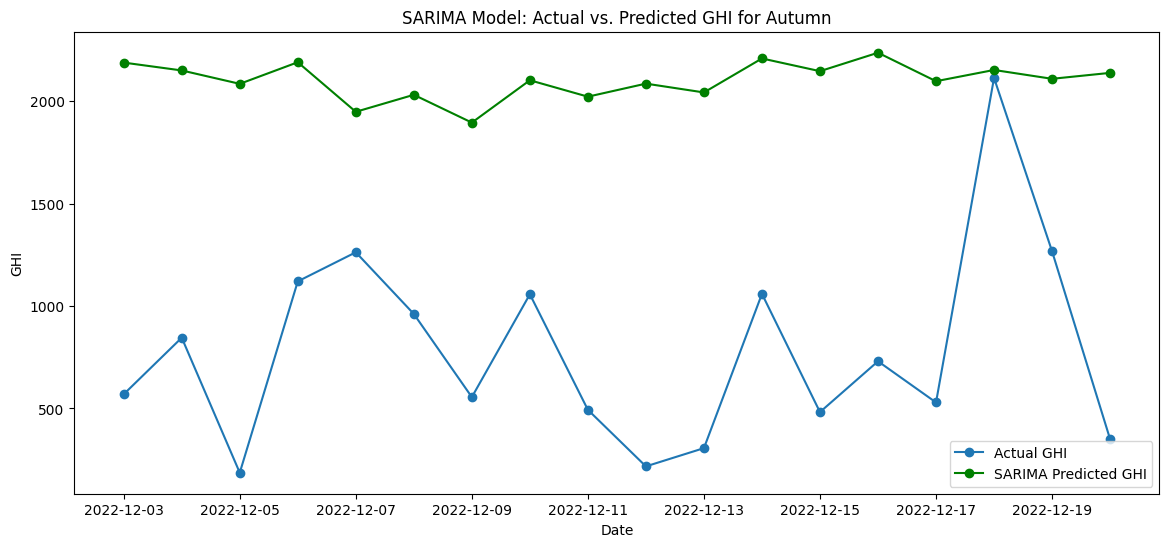

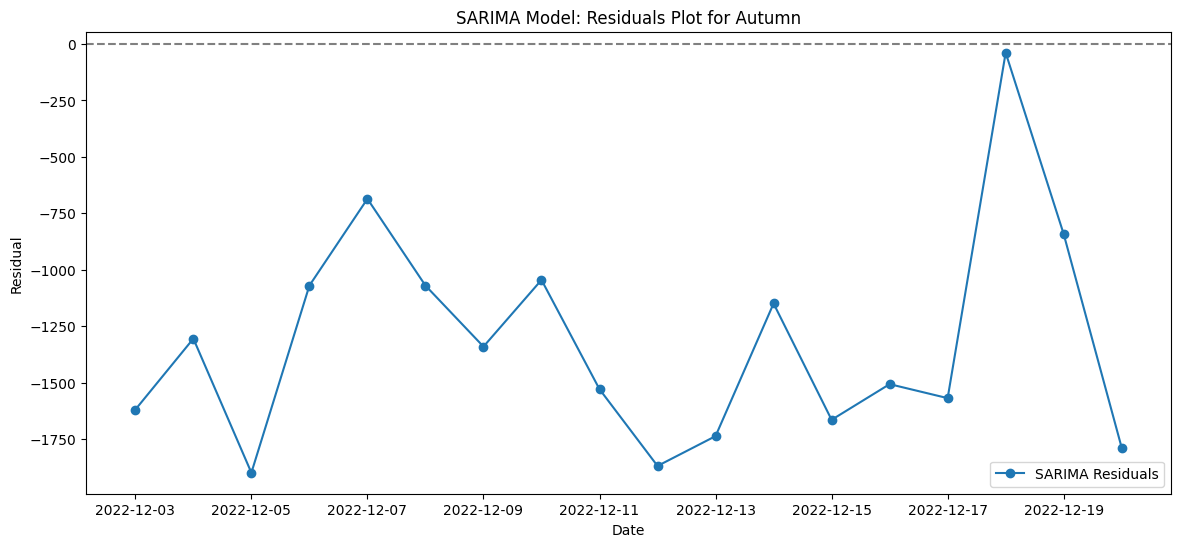

SARIMA Model Metrics for Autumn:
  AIC: 1184.95
  BIC: 1198.52
  MAE: 1317.73
  RMSE: 1397.07

--- Summary of Model Metrics ---
Winter Metrics: {'ARIMA_AIC': np.float64(1149.066377786053), 'ARIMA_BIC': np.float64(1158.0603587542505), 'ARIMA_MAE': 1003.603790704526, 'ARIMA_RMSE': 1291.3853575106548, 'SARIMA_AIC': np.float64(1151.0751056273132), 'SARIMA_BIC': np.float64(1164.5660770796094), 'SARIMA_MAE': 993.1301215970943, 'SARIMA_RMSE': 1258.1594112851228}
Spring Metrics: {'ARIMA_AIC': np.float64(1317.61602711898), 'ARIMA_BIC': np.float64(1329.1363525850009), 'ARIMA_MAE': 1430.8362348580442, 'ARIMA_RMSE': 1799.9160478820856, 'SARIMA_AIC': np.float64(1319.4842668236208), 'SARIMA_BIC': np.float64(1333.308657382846), 'SARIMA_MAE': 1119.6270882699885, 'SARIMA_RMSE': 1333.6363032749227}
Summer Metrics: {'ARIMA_AIC': np.float64(1246.0740979211093), 'ARIMA_BIC': np.float64(1255.235935685703), 'ARIMA_MAE': 1758.667325445269, 'ARIMA_RMSE': 2364.1272667920152, 'SARIMA_AIC': np.float64(1245.520604

In [135]:
# Define orders for each season based on ADF test and general time series characteristics
# (p,d,q) for ARIMA and (P,D,Q,S) for seasonal part of SARIMA

winter_arima_order = (2, 1, 1)
winter_sarima_order = (2, 1, 1)
winter_sarima_seasonal_order = (1, 0, 1, 7)

spring_arima_order = (2, 0, 1)
spring_sarima_order = (2, 0, 1)
spring_sarima_seasonal_order = (1, 0, 1, 7)

summer_arima_order = (2, 1, 1)
summer_sarima_order = (2, 1, 1)
summer_sarima_seasonal_order = (1, 0, 1, 7)

autumn_arima_order = (2, 1, 1)
autumn_sarima_order = (2, 1, 1)
autumn_sarima_seasonal_order = (1, 0, 1, 7)

print("\n--- Evaluating Winter Data ---")
winter_metrics = evaluate_and_plot_model(winter_df, name="Winter", arima_order=winter_arima_order, sarima_order=winter_sarima_order, sarima_seasonal_order=winter_sarima_seasonal_order)

print("\n--- Evaluating Spring Data ---")
spring_metrics = evaluate_and_plot_model(spring_df, name="Spring", arima_order=spring_arima_order, sarima_order=spring_sarima_order, sarima_seasonal_order=spring_sarima_seasonal_order)

print("\n--- Evaluating Summer Data ---")
summer_metrics = evaluate_and_plot_model(summer_df, name="Summer", arima_order=summer_arima_order, sarima_order=summer_sarima_order, sarima_seasonal_order=summer_sarima_seasonal_order)

print("\n--- Evaluating Autumn Data ---")
autumn_metrics = evaluate_and_plot_model(autumn_df, name="Autumn", arima_order=autumn_arima_order, sarima_order=autumn_sarima_order, sarima_seasonal_order=autumn_sarima_seasonal_order)

print("\n--- Summary of Model Metrics ---")
print("Winter Metrics:", winter_metrics)
print("Spring Metrics:", spring_metrics)
print("Summer Metrics:", summer_metrics)
print("Autumn Metrics:", autumn_metrics)

In [84]:
all_metrics = {
    'Winter': winter_metrics,
    'Spring': spring_metrics,
    'Summer': summer_metrics,
    'Autumn': autumn_metrics
}

metrics_df = pd.DataFrame(all_metrics)

print("\n--- Model Metrics Summary ---")
print(metrics_df)


--- Model Metrics Summary ---
                  Winter       Spring       Summer       Autumn
ARIMA_AIC    1149.066378  1293.280107  1246.074098  1183.675398
ARIMA_BIC    1158.060359  1302.441945  1255.235936  1192.726118
ARIMA_MAE    1003.603791  1214.411311  1758.667325  1460.678686
ARIMA_RMSE   1291.385358  1385.287129  2364.127267  1534.067316
SARIMA_AIC   1151.075106  1295.154737  1245.520604  1184.946999
SARIMA_BIC   1164.566077  1308.897494  1259.263361  1198.523078
SARIMA_MAE    993.130122  1247.041171  1811.306108  1317.728710
SARIMA_RMSE  1258.159411  1411.082638  2392.753309  1397.072234


In [136]:
all_metrics = {
    'Winter': winter_metrics,
    'Spring': spring_metrics,
    'Summer': summer_metrics,
    'Autumn': autumn_metrics
}

metrics_df = pd.DataFrame(all_metrics)

print("\n--- Model Metrics Summary ---")
print(metrics_df)


--- Model Metrics Summary ---
                  Winter       Spring       Summer       Autumn
ARIMA_AIC    1149.066378  1317.616027  1246.074098  1183.675398
ARIMA_BIC    1158.060359  1329.136353  1255.235936  1192.726118
ARIMA_MAE    1003.603791  1430.836235  1758.667325  1460.678686
ARIMA_RMSE   1291.385358  1799.916048  2364.127267  1534.067316
SARIMA_AIC   1151.075106  1319.484267  1245.520604  1184.946999
SARIMA_BIC   1164.566077  1333.308657  1259.263361  1198.523078
SARIMA_MAE    993.130122  1119.627088  1811.306108  1317.728710
SARIMA_RMSE  1258.159411  1333.636303  2392.753309  1397.072234


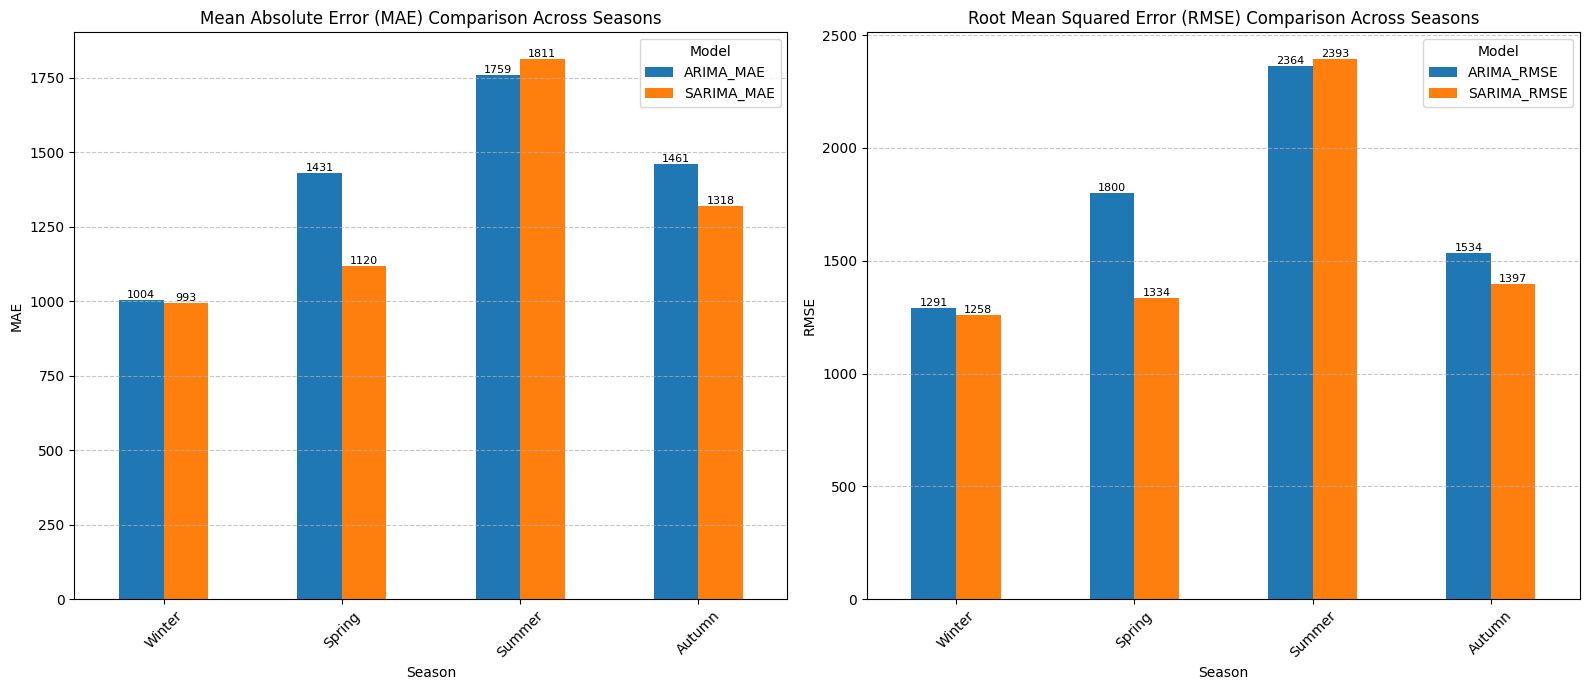

In [137]:


# Prepare data for plotting
metrics_to_plot = metrics_df.loc[['ARIMA_MAE', 'SARIMA_MAE', 'ARIMA_RMSE', 'SARIMA_RMSE']]
metrics_to_plot = metrics_to_plot.T # Transpose to have seasons as index

plt.figure(figsize=(16, 7))

# Plot MAE
plt.subplot(1, 2, 1)
ax_mae = metrics_to_plot[['ARIMA_MAE', 'SARIMA_MAE']].plot(kind='bar', ax=plt.gca())
plt.title('Mean Absolute Error (MAE) Comparison Across Seasons')
plt.xlabel('Season')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars for MAE
for container in ax_mae.containers:
    for i, bar in enumerate(container):
        ax_mae.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

# Plot RMSE
plt.subplot(1, 2, 2)
ax_rmse = metrics_to_plot[['ARIMA_RMSE', 'SARIMA_RMSE']].plot(kind='bar', ax=plt.gca())
plt.title('Root Mean Squared Error (RMSE) Comparison Across Seasons')
plt.xlabel('Season')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars for RMSE
for container in ax_rmse.containers:
    for i, bar in enumerate(container):
        ax_rmse.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

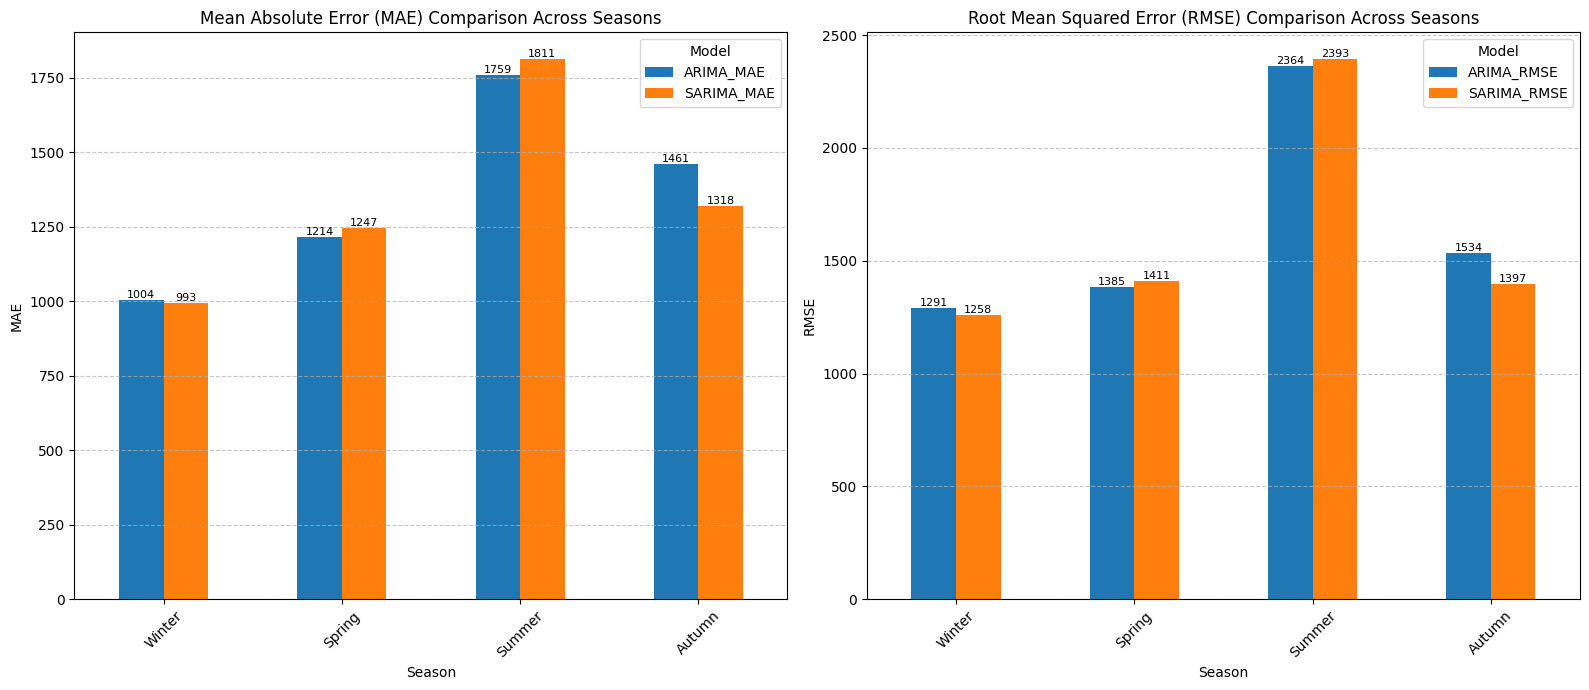

In [128]:


# Prepare data for plotting
metrics_to_plot = metrics_df.loc[['ARIMA_MAE', 'SARIMA_MAE', 'ARIMA_RMSE', 'SARIMA_RMSE']]
metrics_to_plot = metrics_to_plot.T # Transpose to have seasons as index

plt.figure(figsize=(16, 7))

# Plot MAE
plt.subplot(1, 2, 1)
ax_mae = metrics_to_plot[['ARIMA_MAE', 'SARIMA_MAE']].plot(kind='bar', ax=plt.gca())
plt.title('Mean Absolute Error (MAE) Comparison Across Seasons')
plt.xlabel('Season')
plt.ylabel('MAE')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars for MAE
for container in ax_mae.containers:
    for i, bar in enumerate(container):
        ax_mae.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

# Plot RMSE
plt.subplot(1, 2, 2)
ax_rmse = metrics_to_plot[['ARIMA_RMSE', 'SARIMA_RMSE']].plot(kind='bar', ax=plt.gca())
plt.title('Root Mean Squared Error (RMSE) Comparison Across Seasons')
plt.xlabel('Season')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars for RMSE
for container in ax_rmse.containers:
    for i, bar in enumerate(container):
        ax_rmse.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()